# OCRP Checkpoint Walkthrough

This notebook loads a **trained OCRP checkpoint**, pulls a **real test sample**, and walks through the model stage by stage.

The focus is the **upsampler path**:

1. encode LR quaternions into local-iso features
2. apply the LR cosine-masked equivariant conv
3. build the local quaternion and feature banks
4. cluster the quaternion bank into orientation slots
5. build medoid slot contexts
6. do token-conditioned within-slot pooling
7. route the full `4x4` HR patch jointly
8. build per-slot HR patch proposals
9. hard-gather the chosen slot per HR token
10. apply the HR cosine-masked equivariant conv
11. optionally decode to quaternions and render LR/SR/HR IPF maps

Most cells stay in **feature space** so the walkthrough is responsive. The final full-image decode is optional because the decoder is slower than the OCRP feature path.


<!-- code-guide:auto -->
### What This Cell Does

This setup cell finds the repository root, configures temporary cache directories, imports the OCRP model and visualization helpers, and sets print formatting for tensors and arrays.

**Expected:** It should run without printed output. When it finishes, the notebook environment is ready for the remaining cells.


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / 'models').exists():
    candidates = [Path('/data/home/umang/Materials/Reynolds-QSR_4x1'), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'models').exists():
            repo_root = candidate
            break
sys.path.insert(0, str(repo_root))

os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
Path(os.environ['NUMBA_CACHE_DIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from training.config_utils import load_and_prepare_config
from training.quaternion_dataset import QuaternionDataset
from models.SR_ocrp import (
    IsoEmbeddingSROCRP,
    ClusterSlotBuilder,
    _build_local_patch_bank,
    _normalize_quaternions,
)
from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb
from visualization.visualize_sr_results import render_sr_hr_lr_side_by_side

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)


## Notebook Anchor

This notebook is anchored to the OCRP experiment directory:

- experiment: `experiments/IN718/iso_embedding_4x4_ocrp_01`
- checkpoint: `checkpoints/best_model.pt`
- split: `Test`
- sample: configurable with `SAMPLE_IDX`

The model is instantiated directly from the OCRP config so the walkthrough matches the trained run as closely as possible.


<!-- code-guide:auto -->
### What This Cell Does

This cell defines the experiment paths, runtime options, and helper utilities used throughout the walkthrough, including quaternion reshaping, checkpoint loading, and OCRP probing helpers.

**Expected:** It should also run quietly. The main result is that all reusable functions and constants are available for the later analysis cells.


In [2]:
EXP_DIR = repo_root / 'experiments' / 'IN718' / 'iso_embedding_4x4_ocrp_01'
CONFIG_NAME = 'config_new.json'
CHECKPOINT_NAME = 'best_model.pt'
SPLIT = 'Test'
SAMPLE_IDX = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def flatten_quat_image(q: torch.Tensor):
    if q.dim() != 3:
        raise ValueError(f'Expected rank-3 quaternion image, got {tuple(q.shape)}')
    if q.shape[0] == 4:
        h, w = int(q.shape[1]), int(q.shape[2])
        return q.permute(1, 2, 0).reshape(h * w, 4), (h, w)
    if q.shape[-1] == 4:
        h, w = int(q.shape[0]), int(q.shape[1])
        return q.reshape(h * w, 4), (h, w)
    raise ValueError(f'Quaternion axis must be dim=0 or dim=-1 with size 4, got {tuple(q.shape)}')

def to_hwc_quat(q_like, hw=None):
    if isinstance(q_like, torch.Tensor):
        q_like = q_like.detach().cpu()
    arr = np.asarray(q_like)
    if arr.ndim == 2:
        if hw is None:
            raise ValueError('Need hw for flat quaternion arrays')
        return arr.reshape(int(hw[0]), int(hw[1]), 4)
    if arr.ndim == 3 and arr.shape[0] == 4:
        return np.transpose(arr, (1, 2, 0))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        return arr
    raise ValueError(f'Unsupported quaternion array shape: {arr.shape}')

def patch_ipf_rgb(q_patch, sym_class, ref_dir='X'):
    q_patch = np.asarray(q_patch, dtype=np.float32)
    if q_patch.ndim != 3 or q_patch.shape[-1] != 4:
        raise ValueError(f'Expected patch quaternion array (H,W,4), got {q_patch.shape}')
    h, w = q_patch.shape[:2]
    q_line = q_patch.reshape(1, h * w, 4)
    rgb_line = render_ipf_rgb(q_line, sym_class, ref_dir=ref_dir)
    return np.asarray(rgb_line).reshape(h, w, 3)

def build_ocrp_from_cfg(cfg, device):
    model = IsoEmbeddingSROCRP(
        crystal=cfg.crystal,
        d6_convention=cfg.d6_convention,
        device=device,
        feature_irreps=cfg.feature_irreps,
        use_lr_conv1=cfg.use_lr_conv1,
        lr_conv1_kernel_size=cfg.lr_conv1_kernel_size,
        use_residual_lr1=cfg.use_residual_lr1,
        conv_feature_mask_cosine_threshold=cfg.conv_feature_mask_cosine_threshold,
        conv_feature_mask_soft=cfg.conv_feature_mask_soft,
        conv_feature_mask_temperature=cfg.conv_feature_mask_temperature,
        upsample_factor=cfg.upsample_factor,
        window_size=cfg.window_size,
        kmax_slots=cfg.kmax_slots,
        cluster_threshold_deg=cfg.cluster_threshold_deg,
        cluster_connectivity=cfg.cluster_connectivity,
        phase_dim=cfg.phase_dim,
        ocrp_router_hidden_dim=cfg.ocrp_router_hidden_dim,
        ocrp_router_conv_hidden_dim=cfg.ocrp_router_conv_hidden_dim,
        ocrp_proposal_hidden_dim=cfg.ocrp_proposal_hidden_dim,
        ocrp_straight_through=cfg.ocrp_straight_through,
        use_hr_conv1=cfg.use_hr_conv1,
        hr_conv1_kernel_size=cfg.hr_conv1_kernel_size,
        use_residual_hr1=cfg.use_residual_hr1,
        decoder_cubochoric_resolution=cfg.decoder_cubochoric_resolution,
        decoder_num_starts=cfg.decoder_num_starts,
        decoder_steps=cfg.decoder_steps,
        decoder_lr=cfg.decoder_lr,
        decoder_method=getattr(cfg, 'decoder_method', 'cubochoric'),
        decoder_max_table_rows=cfg.decoder_max_table_rows,
        decoder_table_cache_dir=cfg.decoder_table_cache_dir,
        decoder_eager_init=cfg.decoder_eager_init,
    )
    return model.to(device)

def load_checkpoint_weights(model, checkpoint_path, device):
    try:
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        ckpt = torch.load(checkpoint_path, map_location=device)
    except Exception:
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state_dict = ckpt.get('model_state_dict', ckpt)
    model.load_state_dict(state_dict, strict=True)
    return model.to(device)

def tensor_shape_markdown(stage_map):
    lines = ['| stage | shape | dtype |', '|---|---|---|']
    for name, tensor in stage_map.items():
        if tensor is None:
            lines.append(f'| `{name}` | `None` | `-` |')
        else:
            lines.append(f'| `{name}` | `{tuple(tensor.shape)}` | `{tensor.dtype}` |')
    return '\n'.join(lines)

SLOT_TYPE_NAMES = ['parent', 'alt1', 'alt2', 'null']

def slot_meta_markdown(slot_meta_row, medoid_row, cluster_label_row):
    meta = slot_meta_row.detach().cpu().numpy()
    medoid = medoid_row.detach().cpu().numpy()
    cluster_labels = cluster_label_row.detach().cpu().numpy()
    lines = [
        '| slot | valid | type | mass | centroid_y | centroid_x | spatial_disp | medoid_bank_idx | cluster_label |',
        '|---|---:|---|---:|---:|---:|---:|---:|---:|',
    ]
    for slot_idx in range(meta.shape[0]):
        slot_type_idx = int(np.argmax(
            meta[slot_idx, ClusterSlotBuilder.META_SLOT_TYPE_START:
                 ClusterSlotBuilder.META_SLOT_TYPE_START + ClusterSlotBuilder.SLOT_TYPE_DIM]
        ))
        if 0 <= slot_type_idx < len(SLOT_TYPE_NAMES):
            slot_type_name = SLOT_TYPE_NAMES[slot_type_idx]
        else:
            slot_type_name = f'unk_{slot_type_idx}'
        lines.append(
            '| {} | {:.0f} | {} | {:.3f} | {:.3f} | {:.3f} | {:.3f} | {} | {} |'.format(
                slot_idx + 1,
                meta[slot_idx, ClusterSlotBuilder.META_VALID],
                slot_type_name,
                meta[slot_idx, ClusterSlotBuilder.META_MASS],
                meta[slot_idx, ClusterSlotBuilder.META_CENTROID_Y],
                meta[slot_idx, ClusterSlotBuilder.META_CENTROID_X],
                meta[slot_idx, ClusterSlotBuilder.META_SPATIAL_DISP],
                int(medoid[slot_idx]),
                int(cluster_labels[slot_idx]),
            )
        )
    return '\n'.join(lines)

def window_index_to_xy(win_idx, lr_shape):
    h, w = int(lr_shape[0]), int(lr_shape[1])
    return divmod(int(win_idx), w)

def choose_probe_window(aux):
    owner = aux['owner_idx'][0].detach().cpu()
    slot_valid = aux['slot_valid'][0].detach().cpu().sum(dim=-1)
    multi_owner = torch.tensor([torch.unique(owner[i]).numel() > 1 for i in range(owner.shape[0])])
    candidates = torch.nonzero((slot_valid >= 4) & multi_owner, as_tuple=False)
    if len(candidates) > 0:
        return int(candidates[0, 0].item())
    fallback = torch.nonzero(slot_valid >= 4, as_tuple=False)
    if len(fallback) > 0:
        return int(fallback[0, 0].item())
    return 0



<!-- code-guide:auto -->
### What This Cell Does

This cell loads the config, dataset sample, and trained checkpoint, then runs the encoder and OCRP feature pipeline once so we can inspect the saved intermediate tensors in `aux`.

**Expected:** It should print the experiment path, checkpoint path, selected split/sample, active device, and the LR and HR shapes involved in the forward pass.


In [3]:
cfg = load_and_prepare_config(EXP_DIR / CONFIG_NAME, save_path=None)
sym_class = resolve_symmetry(getattr(cfg, 'symmetry_group', 'Oh'))

dataset = QuaternionDataset(
    cfg.dataset_root,
    split=SPLIT,
    preload=False,
    preload_torch=False,
)
lr_img, hr_img = dataset[SAMPLE_IDX]
lr_flat, lr_shape = flatten_quat_image(lr_img)
hr_flat, hr_shape_gt = flatten_quat_image(hr_img)

model = build_ocrp_from_cfg(cfg, DEVICE)
model = load_checkpoint_weights(model, EXP_DIR / 'checkpoints' / CHECKPOINT_NAME, DEVICE)
model.eval()

with torch.no_grad():
    lr_in = _normalize_quaternions(lr_flat.unsqueeze(0).to(DEVICE))
    feat_lr = model.encode(lr_in)
    feat_hr_post, hr_shape_model, aux = model._forward_sr_features(
        lr_quats=lr_in,
        feat_lr=feat_lr,
        lr_shape=lr_shape,
        return_aux=True,
    )

print(f'Experiment: {EXP_DIR}')
print(f'Checkpoint: {EXP_DIR / "checkpoints" / CHECKPOINT_NAME}')
print(f'Split/sample: {SPLIT}/{SAMPLE_IDX}')
print(f'Device: {DEVICE}')
print(f'LR shape: {lr_shape}, HR target shape: {hr_shape_gt}, HR model shape: {hr_shape_model}')


Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 1 (default: 4)
  - symmetry_group: Oh (default: O)
  - use_amp: True (default: False)
  - decoder_steps: 60 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - save_every: 10 (default: 5)
  - viz_every: 1 (default: 5)
  - viz_sample_key: x_230 (default: None)
  - num_workers: 8 (default: 0)
  - persistent_workers: True (default: False)
  - prefetch_factor: 4 (default: 2)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - cudnn_benchmark: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_ocrp (default: iso_embedding_sr_attn)
  - logging.val_freq: 10 (default: 1)
Using existing symmetry files for Oh
Experiment: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_4x4_ocrp_01
Checkpoint: 

<!-- code-guide:auto -->
### What This Cell Does

This cell collects the most important OCRP intermediate tensors into one dictionary and renders a compact summary table of their shapes and dtypes.

**Expected:** It should display a markdown table showing each stage name, tensor shape, and dtype so you can verify the feature flow at a glance.


In [4]:
stage_map = {
    'lr_in': lr_in,
    'feat_lr': feat_lr,
    'feat_lr_pre_ocrp': aux['feat_lr_pre_ocrp'],
    'bank_q': aux['bank_q'],
    'bank_f': aux['bank_f'],
    'cluster_ids': aux['cluster_ids'],
    'slot_mask': aux['slot_mask'],
    'slot_valid': aux['slot_valid'],
    'slot_meta': aux['slot_meta'],
    'slot_ctx': aux['slot_ctx'],
    'slot_pooled_ctx': aux['slot_pooled_ctx'],
    'slot_pool_alpha': aux['slot_pool_alpha'],
    'router_logits': aux['router_logits'],
    'owner_idx': aux['owner_idx'],
    'patch_prop': aux['patch_prop'],
    'patch_out': aux['patch_out'],
    'feat_hr_raw_ocrp': aux['feat_hr_raw_ocrp'],
    'feat_hr_post_hr_conv': aux['feat_hr_post_hr_conv'],
}
display(Markdown(tensor_shape_markdown(stage_map)))


| stage | shape | dtype |
|---|---|---|
| `lr_in` | `(1, 4096, 4)` | `torch.float32` |
| `feat_lr` | `(1, 4096, 14)` | `torch.float32` |
| `feat_lr_pre_ocrp` | `(1, 4096, 14)` | `torch.float32` |
| `bank_q` | `(1, 4096, 81, 4)` | `torch.float32` |
| `bank_f` | `(1, 4096, 81, 14)` | `torch.float32` |
| `cluster_ids` | `(1, 4096, 81)` | `torch.int64` |
| `slot_mask` | `(1, 4096, 10, 81)` | `torch.bool` |
| `slot_valid` | `(1, 4096, 10)` | `torch.float32` |
| `slot_meta` | `(1, 4096, 10, 25)` | `torch.float32` |
| `slot_ctx` | `(1, 4096, 10, 14)` | `torch.float32` |
| `slot_pooled_ctx` | `(1, 4096, 10, 16, 14)` | `torch.float32` |
| `slot_pool_alpha` | `(1, 4096, 10, 16, 81)` | `torch.float32` |
| `router_logits` | `(1, 4096, 16, 10)` | `torch.float32` |
| `owner_idx` | `(1, 4096, 16)` | `torch.int64` |
| `patch_prop` | `(1, 4096, 10, 16, 14)` | `torch.float32` |
| `patch_out` | `(1, 4096, 16, 14)` | `torch.float32` |
| `feat_hr_raw_ocrp` | `(1, 65536, 14)` | `torch.float32` |
| `feat_hr_post_hr_conv` | `(1, 65536, 14)` | `torch.float32` |

## Manual OCRP Step-Through

The next cell reproduces the OCRP upsampler explicitly from its submodules and checks that the manual reconstruction matches the tensors cached in `aux`.


<!-- code-guide:auto -->
### What This Cell Does

This cell reconstructs the OCRP path step by step by hand, from local patch banks through routing and patch assembly, and then compares each manually built tensor with the stored forward-pass outputs.

**Expected:** It should return a dictionary of maximum absolute differences. The values are expected to be very small, ideally at or near numerical precision, which confirms the walkthrough matches the model internals.


In [5]:
with torch.no_grad():
    feat_pre_manual = model.conv_lr1(feat_lr, lr_shape) if model.use_lr_conv1 else feat_lr

    bank_q = _build_local_patch_bank(lr_in, img_shape=lr_shape, window_size=model.ocrp.window_size)
    bank_f = _build_local_patch_bank(feat_pre_manual, img_shape=lr_shape, window_size=model.ocrp.window_size)

    cluster_ids = model.ocrp.clusterer(bank_q)
    slot_info = model.ocrp.slot_builder(cluster_ids)
    slot_ctx, medoid_bank_idx = model.ocrp.context_builder(
        bank_q=bank_q,
        bank_f=bank_f,
        slot_mask=slot_info['slot_mask'],
        slot_meta=slot_info['slot_meta'],
    )
    phase_grid = model.ocrp._phase_grid(device=feat_lr.device, dtype=feat_lr.dtype)
    slot_pooled_ctx, slot_pool_alpha = model.ocrp.slot_pool(
        slot_anchor_ctx=slot_ctx,
        slot_meta=slot_info['slot_meta'],
        bank_f=bank_f,
        slot_mask=slot_info['slot_mask'],
        phase_grid=phase_grid,
        return_alpha=True,
    )
    router_logits = model.ocrp.router(
        slot_ctx=slot_ctx,
        slot_meta=slot_info['slot_meta'],
        phase_grid=phase_grid,
        weak_parent_prior=feat_pre_manual,
    )
    owner_idx_manual, owner_onehot_manual = model.ocrp._hard_owner_from_logits(
        router_logits,
        straight_through=False,
    )
    patch_prop = model.ocrp.proposal_head(
        slot_ctx=slot_pooled_ctx,
        slot_meta=slot_info['slot_meta'],
        phase_grid=phase_grid,
        weak_parent_prior=feat_pre_manual,
        slot_anchor_ctx=slot_ctx,
    )
    owner_mask = owner_onehot_manual.permute(0, 1, 3, 2).unsqueeze(-1)
    patch_out = (owner_mask * patch_prop).sum(dim=2)
    feat_hr_raw_manual = model.ocrp._assemble_patch_tokens(patch_out, lr_shape=lr_shape)
    feat_hr_post_manual = model.conv_hr1(feat_hr_raw_manual, hr_shape_model) if model.use_hr_conv1 else feat_hr_raw_manual

max_diffs = {
    'feat_lr_pre_ocrp': float((feat_pre_manual - aux['feat_lr_pre_ocrp']).abs().max().item()),
    'bank_q': float((bank_q - aux['bank_q']).abs().max().item()),
    'cluster_ids': float((cluster_ids - aux['cluster_ids']).abs().max().item()),
    'slot_ctx': float((slot_ctx - aux['slot_ctx']).abs().max().item()),
    'slot_pooled_ctx': float((slot_pooled_ctx - aux['slot_pooled_ctx']).abs().max().item()),
    'router_logits': float((router_logits - aux['router_logits']).abs().max().item()),
    'patch_prop': float((patch_prop - aux['patch_prop']).abs().max().item()),
    'patch_out': float((patch_out - aux['patch_out']).abs().max().item()),
    'feat_hr_raw_ocrp': float((feat_hr_raw_manual - aux['feat_hr_raw_ocrp']).abs().max().item()),
    'feat_hr_post_hr_conv': float((feat_hr_post_manual - aux['feat_hr_post_hr_conv']).abs().max().item()),
}
max_diffs


{'feat_lr_pre_ocrp': 0.0,
 'bank_q': 0.0,
 'cluster_ids': 0.0,
 'slot_ctx': 0.0,
 'slot_pooled_ctx': 0.0,
 'router_logits': 4.076957702636719e-05,
 'patch_prop': 0.0,
 'patch_out': 0.0,
 'feat_hr_raw_ocrp': 0.0,
 'feat_hr_post_hr_conv': 0.0}

<!-- code-guide:auto -->
### What This Cell Does

This cell computes global routing statistics across all windows, including how many valid slots appear, how often multiple slots are used inside one HR patch, and how confident the router is.

**Expected:** It should print histograms and a top1-top2 margin summary that help you judge how selective and decisive the OCRP routing behavior is on this sample.


In [6]:
slot_count = aux['slot_valid'][0].sum(dim=-1).detach().cpu()
owner = aux['owner_idx'][0].detach().cpu()
probs = torch.softmax(aux['router_logits'][0].detach().cpu(), dim=-1)
top2 = torch.topk(probs, k=2, dim=-1).values
margin = top2[..., 0] - top2[..., 1]

windows_with_multi_owner = int(sum(torch.unique(owner[i]).numel() > 1 for i in range(owner.shape[0])))
slot_hist = torch.bincount(slot_count.to(torch.int64), minlength=int(slot_count.max().item()) + 1)
owner_hist = torch.bincount(owner.reshape(-1), minlength=model.ocrp.kmax_slots)

print('Windows by valid slot count:')
for idx, count in enumerate(slot_hist.tolist()):
    print(f'  {idx} valid slots: {count}')
print(f'Windows whose 4x4 patch uses more than one slot: {windows_with_multi_owner}/{owner.shape[0]}')
print('Owner-slot histogram across all HR tokens:')
for slot_idx, count in enumerate(owner_hist.tolist()):
    print(f'  slot {slot_idx + 1}: {count}')
print(f'Router top1-top2 margin: mean={margin.mean().item():.4f}, median={margin.median().item():.4f}, min={margin.min().item():.4f}')


Windows by valid slot count:
  0 valid slots: 0
  1 valid slots: 708
  2 valid slots: 894
  3 valid slots: 795
  4 valid slots: 572
  5 valid slots: 434
  6 valid slots: 259
  7 valid slots: 168
  8 valid slots: 143
  9 valid slots: 70
  10 valid slots: 53
Windows whose 4x4 patch uses more than one slot: 0/4096
Owner-slot histogram across all HR tokens:
  slot 1: 62080
  slot 2: 2896
  slot 3: 560
  slot 4: 0
  slot 5: 0
  slot 6: 0
  slot 7: 0
  slot 8: 0
  slot 9: 0
  slot 10: 0
Router top1-top2 margin: mean=0.6110, median=0.6713, min=0.0002


<!-- code-guide:auto -->
### What This Cell Does

This cell defines a reusable visualization helper for a single LR window. The helper plots cluster assignments, selected owners, routing margins, pooling maps, slot metadata, and decoded slot proposals.

**Expected:** It is a definition-only cell, so it should not display anything yet. After it runs, `show_window_probe(...)` is available for targeted inspection.


In [7]:
def show_window_probe(win_idx, ref_dir='X'):
    from matplotlib import patheffects as pe
    from models.SR_ocrp import _misorientation_angle_sym
    import math

    win_y, win_x = window_index_to_xy(win_idx, lr_shape)
    window = model.ocrp.window_size
    r = model.ocrp.upsample_factor
    if isinstance(r, (tuple, list)):
        r_h, r_w = int(r[0]), int(r[1])
    else:
        r_h, r_w = int(r), int(r)

    slot_mask_src = slot_info['slot_mask'] if 'slot_mask' in slot_info else aux['slot_mask']
    slot_mask_win = slot_mask_src[0, win_idx].detach().cpu()
    if slot_mask_win.dim() == 2:
        slot_id_flat = torch.full((slot_mask_win.shape[1],), -1, dtype=torch.long)
        for s in range(slot_mask_win.shape[0]):
            slot_id_flat[slot_mask_win[s] > 0.5] = s
        slot_id_map = slot_id_flat.reshape(window, window).numpy()
    else:
        slot_id_map = torch.full((window, window), -1, dtype=torch.long).numpy()
        for s in range(slot_mask_win.shape[0]):
            slot_id_map[slot_mask_win[s] > 0.5] = s

    lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
    lr_q_patch = lr_q_img[win_y:win_y + window, win_x:win_x + window]
    lr_ipf_patch = patch_ipf_rgb(lr_q_patch, sym_class, ref_dir=ref_dir)

    # Ensure all tensors for misorientation live on CPU to avoid device mismatches
    q_patch = torch.tensor(lr_q_patch, dtype=torch.float32).cpu()
    sym_ops = model.ocrp.clusterer.sym_ops_mat.detach().to(dtype=torch.float32).cpu()

    # Compute misorientation either to the center quaternion (default) or to a
    # canonical quaternion corresponding to the chosen IPF reference direction.
    ref = str(ref_dir).upper()
    N = int(window * window)
    q1 = q_patch.reshape(N, 4).to(sym_ops.device)

    if ref in ('X', 'Y', 'Z'):
        c = math.cos(math.pi / 4.0)  # cos(45°)
        s = math.sin(math.pi / 4.0)  # sin(45°)
        if ref == 'X':
            # identity (no rotation): crystal X -> sample X
            q_ref = torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=torch.float32, device=sym_ops.device)
        elif ref == 'Y':
            # rotate +90° about Z to map X -> Y
            q_ref = torch.tensor([c, 0.0, 0.0, s], dtype=torch.float32, device=sym_ops.device)
        else:  # 'Z'
            # rotate -90° about Y to map X -> Z
            q_ref = torch.tensor([c, 0.0, -s, 0.0], dtype=torch.float32, device=sym_ops.device)

        q2 = q_ref.unsqueeze(0).expand(N, 4).to(sym_ops.device)
        mis = _misorientation_angle_sym(q1, q2, sym_ops)
    else:
        # fallback: misorientation to patch center quaternion
        q_center = q_patch[window // 2, window // 2].to(dtype=torch.float32).to(sym_ops.device)
        q2 = q_center.unsqueeze(0).expand(N, 4).to(sym_ops.device)
        mis = _misorientation_angle_sym(q1, q2, sym_ops)

    mis_map = (mis.reshape(window, window) * (180.0 / np.pi)).cpu().numpy()

    owner_patch = aux['owner_idx'][0, win_idx].detach().cpu().reshape(r_h, r_w).numpy()
    probs_patch = torch.softmax(aux['router_logits'][0, win_idx].detach().cpu(), dim=-1)
    topk_patch = torch.topk(probs_patch, k=2, dim=-1).values
    margin_patch = (topk_patch[:, 0] - topk_patch[:, 1]).reshape(r_h, r_w).numpy()

    slot_valid = aux['slot_valid'][0, win_idx].detach().cpu().numpy()
    valid_slots = [i for i, v in enumerate(slot_valid.tolist()) if v > 0.5]
    ncols = max(4, len(valid_slots))
    fig, axes = plt.subplots(2, ncols, figsize=(4.0 * ncols, 7.0))
    axes = np.asarray(axes)

    axes[0, 0].imshow(lr_ipf_patch, interpolation='nearest')
    axes[0, 0].set_title(f'LR IPF patch + slot IDs | window ({win_y}, {win_x}) | IPF-{ref_dir}')
    axes[0, 0].axis('off')
    for y in range(slot_id_map.shape[0]):
        for x in range(slot_id_map.shape[1]):
            slot_id = int(slot_id_map[y, x])
            label = str(slot_id + 1) if slot_id >= 0 else '.'
            axes[0, 0].text(
                x,
                y,
                label,
                color='white',
                ha='center',
                va='center',
                fontsize=7,
                fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='black')],
            )

    im1 = axes[0, 1].imshow(owner_patch, cmap='tab10', vmin=0, vmax=max(0, model.ocrp.kmax_slots - 1), interpolation='nearest')
    axes[0, 1].set_title('owner_idx over 4x4 HR patch')
    axes[0, 1].axis('off')
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    im2 = axes[0, 2].imshow(margin_patch, cmap='magma', interpolation='nearest')
    axes[0, 2].set_title('router top1-top2 margin')
    axes[0, 2].axis('off')
    fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

    im3 = axes[0, 3].imshow(mis_map, cmap='viridis', interpolation='nearest')
    axes[0, 3].set_title(f'LR misorientation to {ref_dir} (deg)')
    axes[0, 3].axis('off')

    for j in range(4, ncols):
        axes[0, j].axis('off')

    medoid_bank_idx = aux.get('medoid_bank_idx')
    if medoid_bank_idx is None:
        medoid_bank_idx = torch.full(
            (1, slot_info['slot_meta'].shape[1], slot_info['slot_meta'].shape[2]),
            -1,
            device=slot_info['slot_meta'].device,
            dtype=torch.long,
        )

    for j, slot_idx in enumerate(valid_slots):
        alpha_mean = aux['slot_pool_alpha'][0, win_idx, slot_idx].detach().cpu().mean(dim=0).reshape(window, window).numpy()
        axes[1, j].imshow(alpha_mean, cmap='viridis', interpolation='nearest')
        if (aux.get('medoid_bank_idx') is not None) and (medoid_bank_idx[0, win_idx, slot_idx] >= 0):
            my, mx = divmod(int(medoid_bank_idx[0, win_idx, slot_idx].item()), window)
            axes[1, j].scatter([mx], [my], c='red', marker='x', s=70)
        axes[1, j].set_title(f'slot {slot_idx + 1} mean pool alpha')
        axes[1, j].axis('off')
    for j in range(len(valid_slots), ncols):
        axes[1, j].axis('off')

    plt.tight_layout()
    plt.show()

    display(Markdown(slot_meta_markdown(
        slot_info['slot_meta'][0, win_idx],
        medoid_bank_idx[0, win_idx],
        slot_info['slot_cluster_label'][0, win_idx],
    )))

    decoded_patches = []
    with torch.enable_grad():
        final_patch_q = model.decode(aux['patch_out'][0, win_idx].unsqueeze(0)).squeeze(0).detach().cpu()
        decoded_patches.append(('selected patch', to_hwc_quat(final_patch_q, (r_h, r_w))))
        for slot_idx in valid_slots:
            slot_patch_q = model.decode(aux['patch_prop'][0, win_idx, slot_idx].unsqueeze(0)).squeeze(0).detach().cpu()
            decoded_patches.append((f'slot {slot_idx + 1} proposal', to_hwc_quat(slot_patch_q, (r_h, r_w))))

    fig, axes = plt.subplots(1, len(decoded_patches), figsize=(3.5 * len(decoded_patches), 3.5))
    if len(decoded_patches) == 1:
        axes = [axes]
    for ax, (title, q_patch) in zip(axes, decoded_patches):
        rgb = patch_ipf_rgb(q_patch, sym_class, ref_dir=ref_dir)
        ax.imshow(rgb, interpolation='nearest')
        ax.set_title(f'{title} | IPF-{ref_dir}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [8]:
def show_window_misorientation_spatial_analysis(win_idx, ref_dir='X', mis_target='center'):
    """
    Visualize LR window with IPF decoding alongside a 2D spatial-misorientation map.
    Also show per-cluster within-cluster misorientation (each pixel vs its slot center).
    
    Args:
        win_idx: Window index in the flattened LR grid
        ref_dir: IPF reference direction ('X', 'Y', 'Z', or 'center' for patch center)
        mis_target: How to compute misorientation ('center' or ref_dir-based)
    """
    from matplotlib import patheffects as pe
    from models.SR_ocrp import _misorientation_angle_sym
    import math

    win_y, win_x = window_index_to_xy(win_idx, lr_shape)
    window = model.ocrp.window_size

    # Extract LR quaternion patch
    lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
    lr_q_patch = lr_q_img[win_y:win_y + window, win_x:win_x + window]

    # Render IPF
    lr_ipf_patch = patch_ipf_rgb(lr_q_patch, sym_class, ref_dir=ref_dir)

    # Compute misorientation to ref_dir
    q_patch = torch.tensor(lr_q_patch, dtype=torch.float32).cpu()
    sym_ops = model.ocrp.clusterer.sym_ops_mat.detach().to(dtype=torch.float32).cpu()

    ref = str(ref_dir).upper()
    N = int(window * window)
    q1 = q_patch.reshape(N, 4).to(sym_ops.device)

    if ref in ('X', 'Y', 'Z'):
        c = math.cos(math.pi / 4.0)
        s = math.sin(math.pi / 4.0)
        if ref == 'X':
            q_ref = torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=torch.float32, device=sym_ops.device)
        elif ref == 'Y':
            q_ref = torch.tensor([c, 0.0, 0.0, s], dtype=torch.float32, device=sym_ops.device)
        else:  # 'Z'
            q_ref = torch.tensor([c, 0.0, -s, 0.0], dtype=torch.float32, device=sym_ops.device)
        q2 = q_ref.unsqueeze(0).expand(N, 4).to(sym_ops.device)
        mis = _misorientation_angle_sym(q1, q2, sym_ops)
    else:
        q_center = q_patch[window // 2, window // 2].to(dtype=torch.float32).to(sym_ops.device)
        q2 = q_center.unsqueeze(0).expand(N, 4).to(sym_ops.device)
        mis = _misorientation_angle_sym(q1, q2, sym_ops)

    mis_map = (mis.reshape(window, window) * (180.0 / np.pi)).cpu().numpy()

    # Extract slot assignments for this window
    slot_mask_src = slot_info['slot_mask'] if 'slot_mask' in slot_info else aux['slot_mask']
    slot_mask_win = slot_mask_src[0, win_idx].detach().cpu()
    
    # Build slot_id_map (which slot each pixel belongs to)
    if slot_mask_win.dim() == 2:
        slot_id_flat = torch.full((slot_mask_win.shape[1],), -1, dtype=torch.long)
        for s in range(slot_mask_win.shape[0]):
            slot_id_flat[slot_mask_win[s] > 0.5] = s
        slot_id_map = slot_id_flat.reshape(window, window).numpy()
    else:
        slot_id_map = torch.full((window, window), -1, dtype=torch.long).numpy()
        for s in range(slot_mask_win.shape[0]):
            slot_id_map[slot_mask_win[s] > 0.5] = s

    # Get valid slots
    slot_valid = aux['slot_valid'][0, win_idx].detach().cpu().numpy()
    valid_slots = [i for i, v in enumerate(slot_valid.tolist()) if v > 0.5]

    # Compute per-slot within-cluster misorientation (each pixel vs slot center)
    per_slot_mis_maps = {}
    for slot_idx in valid_slots:
        # Get pixels in this slot
        slot_mask = (slot_id_map == slot_idx)
        if not slot_mask.any():
            per_slot_mis_maps[slot_idx] = np.full((window, window), np.nan)
            continue
        
        # Compute center quaternion for this slot (mean of slot pixels)
        slot_pixels = np.where(slot_mask)
        slot_qs = q_patch[slot_pixels[0], slot_pixels[1]]  # (num_pixels, 4)
        q_center_slot = slot_qs.mean(dim=0, keepdim=True)  # (1, 4)
        
        # Compute misorientation from all pixels in slot to slot center
        q_all_flat = q_patch.reshape(window * window, 4).to(sym_ops.device)
        q_center_expanded = q_center_slot.expand(window * window, 4).to(sym_ops.device)
        mis_slot_flat = _misorientation_angle_sym(q_all_flat, q_center_expanded, sym_ops)
        mis_slot = (mis_slot_flat.reshape(window, window) * (180.0 / np.pi)).cpu().numpy()
        
        # Mask out pixels not in this slot
        mis_slot_masked = np.copy(mis_slot)
        mis_slot_masked[~slot_mask] = np.nan
        per_slot_mis_maps[slot_idx] = mis_slot_masked

    # Create figure: top row (IPF + spatial mis), bottom row (per-slot within-cluster mis)
    ncols = max(2, len(valid_slots))
    fig, axes = plt.subplots(2, ncols, figsize=(4.0 * ncols, 9.0))
    if len(valid_slots) + 1 <= ncols:
        axes = np.atleast_2d(axes)

    # Top-left: IPF patch
    axes[0, 0].imshow(lr_ipf_patch, interpolation='nearest')
    axes[0, 0].set_title(f'LR IPF patch (window {win_y}, {win_x}) | ref={ref_dir}', fontweight='bold')
    axes[0, 0].set_xlabel('x (pixel)')
    axes[0, 0].set_ylabel('y (pixel)')
    axes[0, 0].grid(True, alpha=0.3, color='white', linewidth=0.5)

    # Top-right: 2D spatial position plot color-coded by misorientation
    im = axes[0, 1].imshow(mis_map, cmap='viridis', interpolation='nearest', origin='upper')
    axes[0, 1].set_title(f'Misorientation to {ref_dir} (degrees)', fontweight='bold')
    axes[0, 1].set_xlabel('x (pixel)')
    axes[0, 1].set_ylabel('y (pixel)')
    axes[0, 1].grid(True, alpha=0.3, color='white', linewidth=0.5)
    cbar = plt.colorbar(im, ax=axes[0, 1], label='Δmisorientation (°)')

    # Add misorientation values as text on top-right subplot
    for y in range(window):
        for x in range(window):
            mis_val = mis_map[y, x]
            if mis_val < mis_map.min() + 0.4 * (mis_map.max() - mis_map.min()):
                text_color = 'white'
            else:
                text_color = 'black'
            axes[0, 1].text(x, y, f'{mis_val:.1f}°', fontsize=8, ha='center', va='center',
                            color=text_color, fontweight='bold',
                            path_effects=[pe.withStroke(linewidth=0.5, foreground='black' if text_color == 'white' else 'white')])

    # Hide extra top-row subplots
    for j in range(2, ncols):
        axes[0, j].axis('off')

    # Bottom row: per-slot within-cluster misorientation
    for j, slot_idx in enumerate(valid_slots):
        mis_slot_map = per_slot_mis_maps[slot_idx]
        
        # Create masked array for plotting (NaN values shown as white)
        im_slot = axes[1, j].imshow(mis_slot_map, cmap='plasma', interpolation='nearest', origin='upper', vmin=0)
        axes[1, j].set_title(f'Slot {slot_idx + 1}: within-cluster misorientation', fontweight='bold', fontsize=10)
        axes[1, j].set_xlabel('x (pixel)')
        axes[1, j].set_ylabel('y (pixel)')
        axes[1, j].grid(True, alpha=0.3, color='white', linewidth=0.5)
        cbar_slot = plt.colorbar(im_slot, ax=axes[1, j], label='Δmisorientation (°)')

        # Add values as text, only for pixels in this slot
        for y in range(window):
            for x in range(window):
                if slot_id_map[y, x] == slot_idx:  # Only show text for pixels in this slot
                    mis_val = mis_slot_map[y, x]
                    if not np.isnan(mis_val):
                        if mis_val < np.nanmin(mis_slot_map) + 0.4 * (np.nanmax(mis_slot_map) - np.nanmin(mis_slot_map)):
                            text_color = 'white'
                        else:
                            text_color = 'black'
                        axes[1, j].text(x, y, f'{mis_val:.1f}°', fontsize=7, ha='center', va='center',
                                        color=text_color, fontweight='bold',
                                        path_effects=[pe.withStroke(linewidth=0.4, foreground='black' if text_color == 'white' else 'white')])

    # Hide extra bottom-row subplots
    for j in range(len(valid_slots), ncols):
        axes[1, j].axis('off')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f'\nWindow ({win_y}, {win_x}): LR patch misorientation statistics (ref={ref_dir}):')
    print(f'  Mean:   {mis_map.mean():.2f}°')
    print(f'  Median: {np.median(mis_map):.2f}°')
    print(f'  Std:    {mis_map.std():.2f}°')
    print(f'  Min:    {mis_map.min():.2f}°  at pixel {np.unravel_index(np.argmin(mis_map), mis_map.shape)}')
    print(f'  Max:    {mis_map.max():.2f}°  at pixel {np.unravel_index(np.argmax(mis_map), mis_map.shape)}')

    # Show which pixels are near/far from center
    center_y, center_x = window // 2, window // 2
    center_mis = mis_map[center_y, center_x]
    print(f'  Center pixel ({center_y},{center_x}): {center_mis:.2f}°')

    # Per-slot within-cluster statistics
    print(f'\nPer-cluster within-cluster misorientation statistics:')
    for slot_idx in valid_slots:
        mis_slot_map = per_slot_mis_maps[slot_idx]
        valid_vals = mis_slot_map[~np.isnan(mis_slot_map)]
        if len(valid_vals) > 0:
            print(f'  Slot {slot_idx + 1}: mean={valid_vals.mean():.2f}°, median={np.median(valid_vals):.2f}°, '
                  f'std={valid_vals.std():.2f}°, min={valid_vals.min():.2f}°, max={valid_vals.max():.2f}°')


<!-- code-guide:auto -->
### What This Cell Does

This cell picks a representative probe window and calls the visualization helper so you can inspect one local OCRP decision in detail.

**Expected:** It should print the chosen window index and LR coordinates, then render diagnostic plots plus a markdown table describing the valid slots for that window.


Probe window index: 15 -> LR location (0, 15)


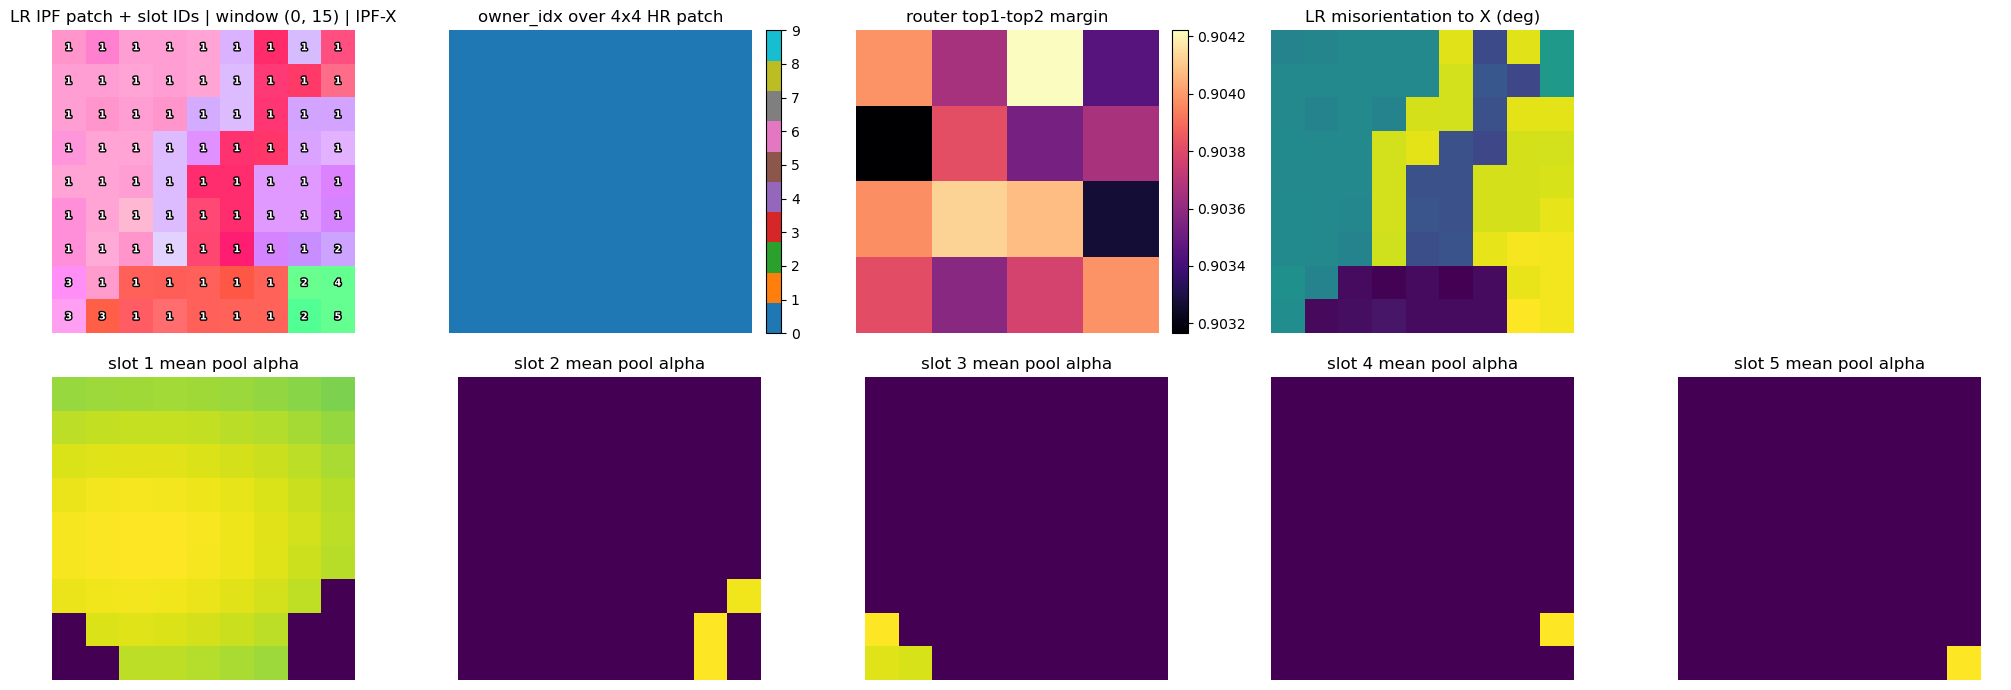

| slot | valid | type | mass | centroid_y | centroid_x | spatial_disp | medoid_bank_idx | cluster_label |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| 1 | 1 | parent | 0.901 | -0.092 | -0.024 | 0.743 | -1 | 0 |
| 2 | 1 | alt1 | 0.037 | 0.750 | 0.833 | 0.056 | -1 | 62 |
| 3 | 1 | alt2 | 0.037 | 0.917 | -0.917 | 0.028 | -1 | 63 |
| 4 | 1 | null | 0.012 | 0.750 | 1.000 | 0.000 | -1 | 71 |
| 5 | 1 | unk_4 | 0.012 | 1.000 | 1.000 | 0.000 | -1 | 80 |
| 6 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 7 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 8 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 9 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 10 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |

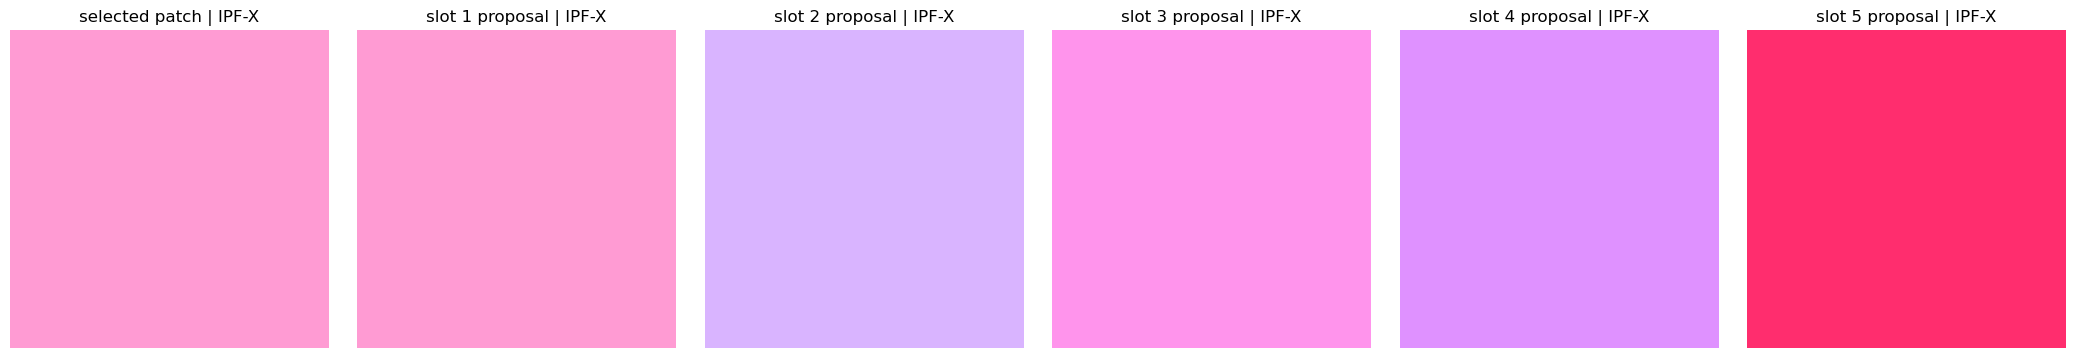

In [9]:
PROBE_WIN_IDX = choose_probe_window(aux)
probe_y, probe_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)
print(f'Probe window index: {PROBE_WIN_IDX} -> LR location ({probe_y}, {probe_x})')
show_window_probe(PROBE_WIN_IDX, ref_dir='X')

LR Window: IPF Decode + Spatial Misorientation Map


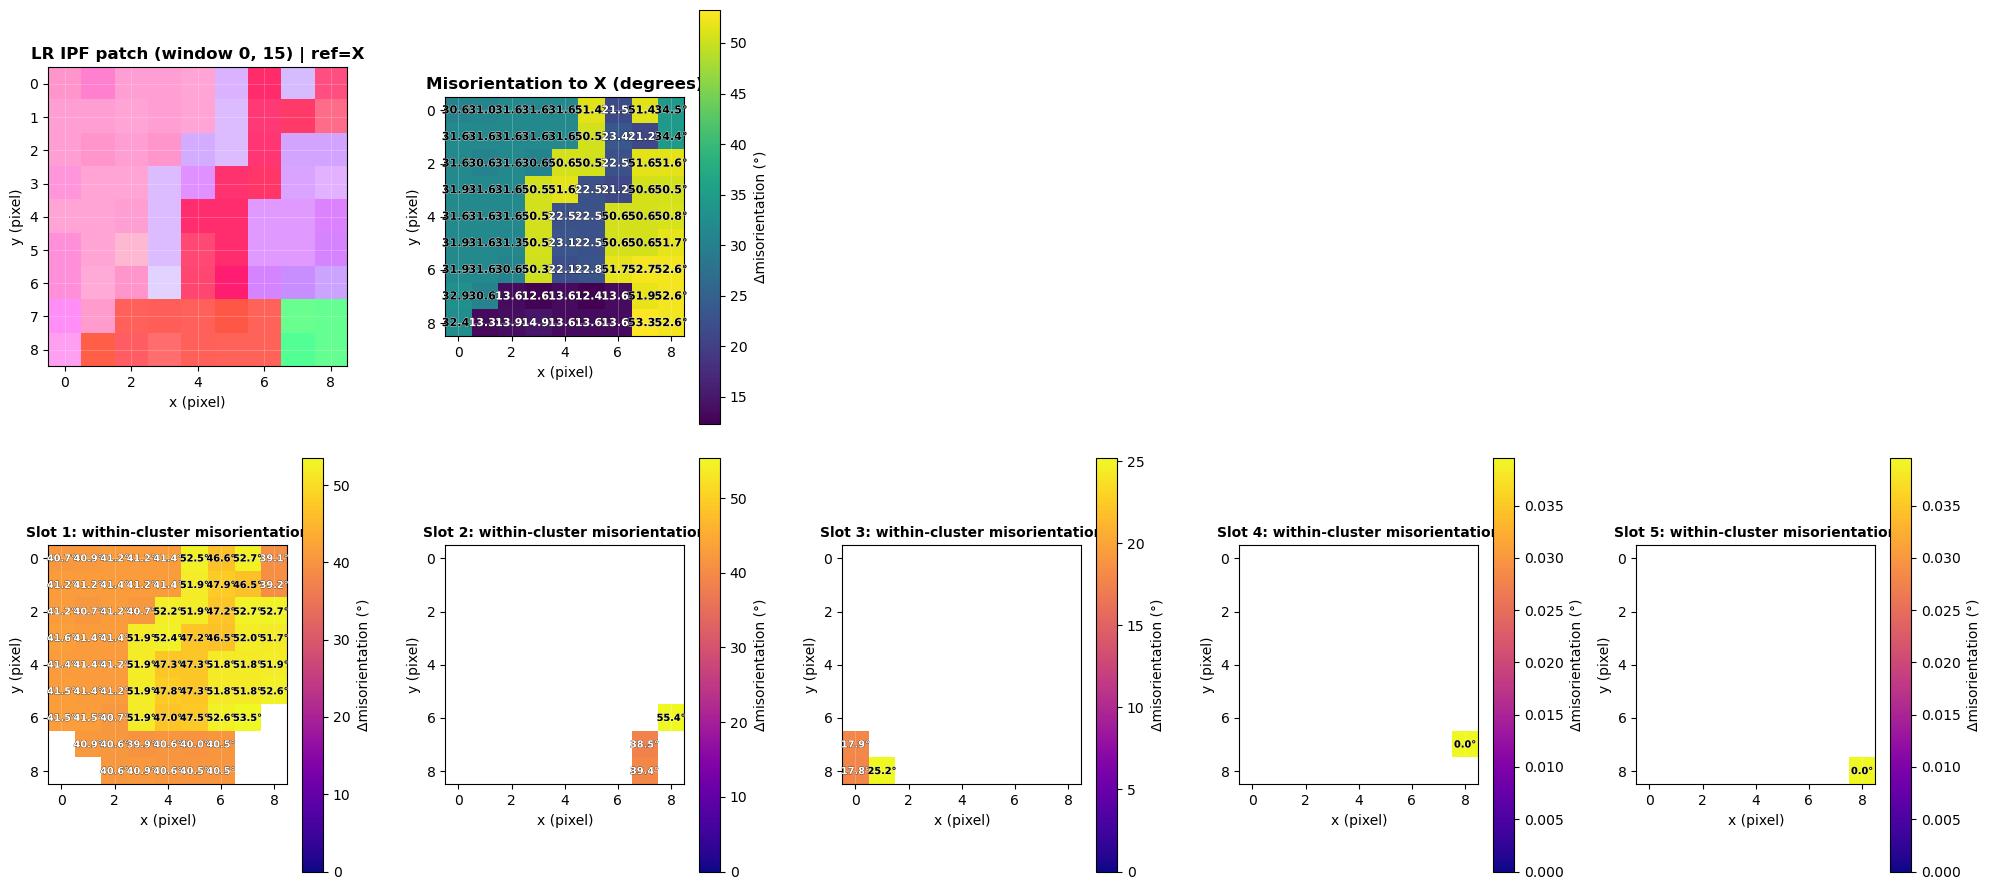


Window (0, 15): LR patch misorientation statistics (ref=X):
  Mean:   34.35°
  Median: 31.59°
  Std:    13.39°
  Min:    12.37°  at pixel (np.int64(7), np.int64(5))
  Max:    53.26°  at pixel (np.int64(8), np.int64(7))
  Center pixel (4,4): 22.46°

Per-cluster within-cluster misorientation statistics:
  Slot 1: mean=45.34°, median=41.50°, std=5.05°, min=39.12°, max=53.52°
  Slot 2: mean=44.45°, median=39.42°, std=7.74°, min=38.54°, max=55.39°
  Slot 3: mean=20.28°, median=17.87°, std=3.48°, min=17.76°, max=25.21°
  Slot 4: mean=0.04°, median=0.04°, std=0.00°, min=0.04°, max=0.04°
  Slot 5: mean=0.04°, median=0.04°, std=0.00°, min=0.04°, max=0.04°


In [10]:
print("="*70)
print("LR Window: IPF Decode + Spatial Misorientation Map")
print("="*70)
show_window_misorientation_spatial_analysis(PROBE_WIN_IDX, ref_dir='X')


## Clustering Algorithm Analysis

The next three cells investigate the root cause of the loose clusters by examining: (1) configuration parameters, (2) the connectivity graph structure, and (3) actual edge misorientation values.


In [11]:
print("="*70)
print("1. CLUSTERING CONFIGURATION")
print("="*70)
print(f"cluster_threshold_deg: {cfg.cluster_threshold_deg}°")
print(f"cluster_connectivity: {cfg.cluster_connectivity}-neighbor (4 or 8)")
print(f"window_size: {model.ocrp.window_size}×{model.ocrp.window_size}")
print(f"num_nodes per window: {model.ocrp.clusterer.num_nodes}")
print()
print("Interpretation:")
print("  The clusterer uses CONNECTIVITY-BASED clustering, NOT tight quaternion clustering.")
print("  It builds a spatial graph (4 or 8-neighbor) and finds connected components where")
print("  adjacent pixels satisfy the misorientation threshold.")
print()
print(f"  Expected behavior: Clusters are SPATIALLY CONTIGUOUS regions. Two pixels can be")
print(f"  in the same cluster even if they are far apart in quaternion space (e.g., 10°),")
print(f"  as long as there's a chain of neighboring pixels each < {cfg.cluster_threshold_deg}° apart.")


1. CLUSTERING CONFIGURATION
cluster_threshold_deg: 2.0°
cluster_connectivity: 8-neighbor (4 or 8)
window_size: 9×9
num_nodes per window: 81

Interpretation:
  The clusterer uses CONNECTIVITY-BASED clustering, NOT tight quaternion clustering.
  It builds a spatial graph (4 or 8-neighbor) and finds connected components where
  adjacent pixels satisfy the misorientation threshold.

  Expected behavior: Clusters are SPATIALLY CONTIGUOUS regions. Two pixels can be
  in the same cluster even if they are far apart in quaternion space (e.g., 10°),
  as long as there's a chain of neighboring pixels each < 2.0° apart.


In [12]:
print("="*70)
print("2. SPATIAL CONNECTIVITY GRAPH STRUCTURE")
print("="*70)
edge_idx_a = model.ocrp.clusterer.edge_idx_a.cpu().numpy()
edge_idx_b = model.ocrp.clusterer.edge_idx_b.cpu().numpy()
num_edges = len(edge_idx_a)
window_size = model.ocrp.window_size

print(f"Total edges in {window_size}×{window_size} window: {num_edges}")
print()

# Categorize edges
edges_dict = {}
for a, b in zip(edge_idx_a, edge_idx_b):
    ay, ax = divmod(int(a), window_size)
    by, bx = divmod(int(b), window_size)
    dy, dx = by - ay, bx - ax
    if (dy, dx) not in edges_dict:
        edges_dict[(dy, dx)] = 0
    edges_dict[(dy, dx)] += 1

print("Edge directions (y_offset, x_offset) -> count:")
for (dy, dx) in sorted(edges_dict.keys()):
    print(f"  ({dy:+d}, {dx:+d}): {edges_dict[(dy, dx)]} edges")

print()
print("Connectivity type verification:")
if cfg.cluster_connectivity == 4:
    print("  4-neighbor: only horizontal and vertical edges (no diagonals)")
elif cfg.cluster_connectivity == 8:
    print("  8-neighbor: horizontal, vertical, AND diagonal edges")

print()
print("Implication:")
print(f"  All {num_edges} edges in the connectivity graph are checked independently.")
print(f"  An edge (i,j) is KEPT only if misorientation(q[i], q[j]) ≤ {cfg.cluster_threshold_deg}°")
print(f"  Connected components emerge from merging nodes along kept edges.")


2. SPATIAL CONNECTIVITY GRAPH STRUCTURE
Total edges in 9×9 window: 272

Edge directions (y_offset, x_offset) -> count:
  (+0, +1): 72 edges
  (+1, -1): 64 edges
  (+1, +0): 72 edges
  (+1, +1): 64 edges

Connectivity type verification:
  8-neighbor: horizontal, vertical, AND diagonal edges

Implication:
  All 272 edges in the connectivity graph are checked independently.
  An edge (i,j) is KEPT only if misorientation(q[i], q[j]) ≤ 2.0°
  Connected components emerge from merging nodes along kept edges.


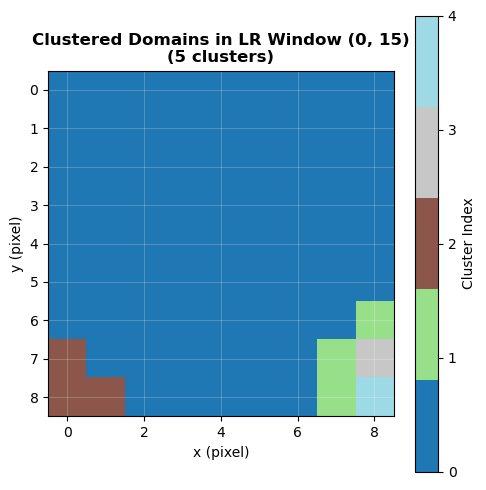

Mapping (original cluster ID → re-indexed cluster number):
  0 → 0
  62 → 1
  63 → 2
  71 → 3
  80 → 4


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Extract cluster IDs for the probe window
win_idx = PROBE_WIN_IDX
win_y, win_x = window_index_to_xy(win_idx, lr_shape)
window = model.ocrp.window_size
cluster_ids_win_raw = aux['cluster_ids'][0, win_idx].detach().cpu().numpy().reshape(window, window)

# Re-index cluster IDs to sequential indices (0, 1, 2, ...)
unique_clusters_raw = np.unique(cluster_ids_win_raw)
num_clusters = len(unique_clusters_raw)

# Create mapping from old ID -> new ID
id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_clusters_raw)}
cluster_ids_win = np.vectorize(id_mapping.get)(cluster_ids_win_raw)

# Visualize re-indexed clusters
plt.figure(figsize=(5, 5))
cmap = plt.get_cmap('tab20', num_clusters)
img = plt.imshow(cluster_ids_win, cmap=cmap, vmin=0, vmax=num_clusters-1, interpolation='nearest')
plt.title(f'Clustered Domains in LR Window ({win_y}, {win_x})\n({num_clusters} clusters)', fontweight='bold')
plt.xlabel('x (pixel)')
plt.ylabel('y (pixel)')
cbar = plt.colorbar(img, ticks=range(num_clusters), label='Cluster Index')
plt.grid(True, alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"Mapping (original cluster ID → re-indexed cluster number):")
for old_id, new_id in sorted(id_mapping.items()):
    print(f"  {old_id} → {new_id}")


In [14]:
print("="*70)
print("CLUSTER SIZE ANALYSIS")
print("="*70)

# Get cluster assignments for this window
win_idx = PROBE_WIN_IDX
win_y, win_x = window_index_to_xy(win_idx, lr_shape)
window = model.ocrp.window_size
cluster_ids_win_flat = aux['cluster_ids'][0, win_idx].detach().cpu().numpy()
cluster_ids_win = cluster_ids_win_flat.reshape(window, window)

# Count pixels in each cluster
unique_ids, counts = np.unique(cluster_ids_win_flat, return_counts=True)

print(f"Unique cluster IDs in this window: {sorted(unique_ids.tolist())}")
print(f"Total unique IDs: {len(unique_ids)}")
print()
print("Pixel count per cluster:")
for cid, count in sorted(zip(unique_ids, counts)):
    percent = 100 * count / (window * window)
    print(f"  Cluster {cid:2d}: {count:2d} pixels ({percent:5.1f}%)")

print()
print("Why you see 4 clusters but the code says 5:")
print("-" * 70)

# Find very small clusters
small_clusters = unique_ids[counts <= 2]
if len(small_clusters) > 0:
    print(f"⚠️  Found {len(small_clusters)} TINY cluster(s):")
    for cid in small_clusters:
        count = counts[unique_ids == cid][0]
        print(f"    Cluster {cid} has only {count} pixel(s) — likely INVISIBLE in visualization!")
else:
    print("✓ All clusters have ≥ 3 pixels.")

print()
print("Most likely explanation:")
if len(small_clusters) > 0:
    print(f"One of the {len(unique_ids)} clusters is too small ({min(counts)} pixels) to see visually.")
    print("It's a real cluster in the connectivity graph, but spatially isolated.")
else:
    print("Discrepancy unexplained — all clusters are reasonably sized.")


CLUSTER SIZE ANALYSIS
Unique cluster IDs in this window: [0, 62, 63, 71, 80]
Total unique IDs: 5

Pixel count per cluster:
  Cluster  0: 73 pixels ( 90.1%)
  Cluster 62:  3 pixels (  3.7%)
  Cluster 63:  3 pixels (  3.7%)
  Cluster 71:  1 pixels (  1.2%)
  Cluster 80:  1 pixels (  1.2%)

Why you see 4 clusters but the code says 5:
----------------------------------------------------------------------
⚠️  Found 2 TINY cluster(s):
    Cluster 71 has only 1 pixel(s) — likely INVISIBLE in visualization!
    Cluster 80 has only 1 pixel(s) — likely INVISIBLE in visualization!

Most likely explanation:
One of the 5 clusters is too small (1 pixels) to see visually.
It's a real cluster in the connectivity graph, but spatially isolated.


In [15]:
print("="*70)
print("3. ACTUAL EDGE MISORIENTATION IN PROBE WINDOW")
print("="*70)
from models.SR_ocrp import _misorientation_angle_sym

win_idx = PROBE_WIN_IDX
win_y, win_x = window_index_to_xy(win_idx, lr_shape)
window = model.ocrp.window_size

# Extract probe window quaternions
lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
lr_q_patch = lr_q_img[win_y:win_y + window, win_x:win_x + window]
q_patch = torch.tensor(lr_q_patch, dtype=torch.float32).cpu()

# Prepare for misorientation calculation
sym_ops = model.ocrp.clusterer.sym_ops_mat.detach().to(dtype=torch.float32).cpu()
edge_idx_a = model.ocrp.clusterer.edge_idx_a.to(device=q_patch.device)
edge_idx_b = model.ocrp.clusterer.edge_idx_b.to(device=q_patch.device)

q_flat = q_patch.reshape(window * window, 4)
q1 = q_flat[edge_idx_a]  # (num_edges, 4)
q2 = q_flat[edge_idx_b]  # (num_edges, 4)
mis_rad = _misorientation_angle_sym(q1, q2, sym_ops.to(q_patch.device))
mis_deg = (mis_rad * 180.0 / np.pi).cpu().numpy()

# Threshold check
threshold = cfg.cluster_threshold_deg
kept_edges = mis_deg <= threshold
num_kept = int(kept_edges.sum())
num_total = len(kept_edges)

print(f"Window ({win_y}, {win_x}): {num_total} spatial edges")
print(f"  Edges with misorientation ≤ {threshold}°: {num_kept} / {num_total} ({100*num_kept/num_total:.1f}%)")
print()

# Statistics on edge misorientation
print(f"Misorientation statistics across all edges:")
print(f"  Mean:   {mis_deg.mean():.2f}°")
print(f"  Median: {np.median(mis_deg):.2f}°")
print(f"  Min:    {mis_deg.min():.2f}°")
print(f"  Max:    {mis_deg.max():.2f}°")
print(f"  Std:    {mis_deg.std():.2f}°")
print()

# Breakdown by kept/broken edges
print(f"Kept edges (≤ {threshold}°):")
if num_kept > 0:
    print(f"  Min:   {mis_deg[kept_edges].min():.2f}°")
    print(f"  Max:   {mis_deg[kept_edges].max():.2f}°")
    print(f"  Mean:  {mis_deg[kept_edges].mean():.2f}°")
print()

broken = ~kept_edges
if broken.sum() > 0:
    print(f"Broken edges (> {threshold}°):")
    print(f"  Min:   {mis_deg[broken].min():.2f}°")
    print(f"  Max:   {mis_deg[broken].max():.2f}°")
    print(f"  Mean:  {mis_deg[broken].mean():.2f}°")
print()

print("Interpretation:")
print(f"  If {num_kept}/{num_total} edges are kept, the connectivity graph is {'DENSE' if num_kept/num_total > 0.7 else 'MODERATE' if num_kept/num_total > 0.3 else 'SPARSE'}.")
print(f"  A dense graph → many large connected components → loose, spatially-spread clusters.")
print(f"  This EXPLAINS the 'fuzziness': clusters are big blobs of neighboring pixels,")
print(f"  not tight quaternion groups.")

# Get cluster IDs for this window
cluster_ids_win = aux['cluster_ids'][0, win_idx].detach().cpu()
unique_clusters = torch.unique(cluster_ids_win)
print()
print(f"Clustering result for this window: {len(unique_clusters)} clusters")
print(f"  Cluster IDs: {sorted([int(c.item()) for c in unique_clusters])}")


3. ACTUAL EDGE MISORIENTATION IN PROBE WINDOW
Window (0, 15): 272 spatial edges
  Edges with misorientation ≤ 2.0°: 158 / 272 (58.1%)

Misorientation statistics across all edges:
  Mean:   20.04°
  Median: 1.41°
  Min:    0.00°
  Max:    60.02°
  Std:    25.39°

Kept edges (≤ 2.0°):
  Min:   0.00°
  Max:   2.00°
  Mean:  0.84°

Broken edges (> 2.0°):
  Min:   2.00°
  Max:   60.02°
  Mean:  46.64°

Interpretation:
  If 158/272 edges are kept, the connectivity graph is MODERATE.
  A dense graph → many large connected components → loose, spatially-spread clusters.
  This EXPLAINS the 'fuzziness': clusters are big blobs of neighboring pixels,
  not tight quaternion groups.

Clustering result for this window: 5 clusters
  Cluster IDs: [0, 62, 63, 71, 80]


## Diagnostic: Why is the parent cluster ~45° wide?

Two hypotheses for the loose parent slot:

1. **Chaining** — every kept edge satisfies the 2° threshold, but a long path through the
   8-neighbor graph accumulates large misorientation across a smooth gradient.
2. **Bug** — some edge in the parent's kept-edge graph actually has misorientation > 2°
   (e.g., dtype/sym-op mismatch between training and inference).

This cell tests both directly: it recomputes every edge's misorientation with the same
symmetry operators the clusterer used, walks the kept-edge graph from the most-extreme
pair of parent pixels, and reports whether the chain is a smooth accumulation of small
edges or contains a single threshold-violating edge.

In [16]:
# DIAGNOSTIC: locate the chain that lets the parent slot span ~45° of misorientation.
import collections, heapq
import numpy as np
import torch
from models.SR_ocrp import _misorientation_angle_sym

W = model.ocrp.window_size
N = W * W
threshold_deg = float(np.rad2deg(model.ocrp.clusterer.threshold_rad))
conn = int(model.ocrp.clusterer.connectivity)
print(f'window={W}x{W}  N={N}  threshold={threshold_deg}°  connectivity={conn}')

# 1) LR quaternions of the probe window.
win_y, win_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)
lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
q_flat = torch.tensor(
    lr_q_img[win_y:win_y + W, win_x:win_x + W], dtype=torch.float32
).reshape(N, 4)

# 2) Parent slot membership (slot_idx 0; printed as 'slot 1' in the table).
slot_mask_win = aux['slot_mask'][0, PROBE_WIN_IDX].detach().cpu()
parent_idx = torch.where(slot_mask_win[0] > 0.5)[0]
parent_set = set(parent_idx.tolist())
M = int(parent_idx.numel())
print(f'parent slot covers {M}/{N} pixels')

# 3) Recompute every clusterer edge using the same sym ops registered on the model.
sym_ops = model.ocrp.clusterer.sym_ops_mat.detach().cpu().to(torch.float32)
ea = model.ocrp.clusterer.edge_idx_a.cpu().numpy()
eb = model.ocrp.clusterer.edge_idx_b.cpu().numpy()
em = (_misorientation_angle_sym(q_flat[ea], q_flat[eb], sym_ops)
      * 180.0 / np.pi).numpy()

# 4) Audit edges with both endpoints in the parent slot.
in_parent = np.array([(int(a) in parent_set) and (int(b) in parent_set)
                      for a, b in zip(ea, eb)])
kept_mask = (em <= threshold_deg)
n_in_parent = int(in_parent.sum())
n_kept_in_parent = int((in_parent & kept_mask).sum())
n_drop_in_parent = int((in_parent & ~kept_mask).sum())
print(f'\nedges with both endpoints in parent: {n_in_parent} '
      f'(kept={n_kept_in_parent}, dropped={n_drop_in_parent})')
if n_kept_in_parent:
    kept_em = em[in_parent & kept_mask]
    print(f'  kept-edge mis (deg): min={kept_em.min():.4f}  '
          f'max={kept_em.max():.4f}  mean={kept_em.mean():.4f}')

# 5) Build kept-edge adjacency (over the whole window, not just parent).
adj = collections.defaultdict(dict)
for a, b, m, k in zip(ea, eb, em, kept_mask):
    if k:
        adj[int(a)][int(b)] = float(m)
        adj[int(b)][int(a)] = float(m)

# 6) BFS from a parent seed: should reach every parent pixel and nothing outside.
seen = set(); root = int(parent_idx[0].item())
queue = collections.deque([root])
while queue:
    u = queue.popleft()
    if u in seen:
        continue
    seen.add(u)
    for v in adj[u]:
        if v not in seen:
            queue.append(v)
missing = parent_set - seen
leaked = seen - parent_set
print(f'\nBFS from a parent seed reaches {len(seen)} pixels: '
      f'{len(seen & parent_set)} in parent, {len(leaked)} outside parent.')
if missing:
    print(f'  [!] {len(missing)} parent pixels NOT reachable from seed -> '
          f'slot bundles disjoint kept-edge components (slot-builder bug).')
if leaked:
    print(f'  [!] {len(leaked)} non-parent pixels reachable -> slot membership '
          f'and kept-edge component disagree.')

# 7) Pairwise within-parent symmetry-aware misorientation.
qp = q_flat[parent_idx]
mis_mat = np.zeros((M, M), dtype=np.float32)
for i in range(M):
    mis_mat[i] = (_misorientation_angle_sym(
        qp[i:i + 1].expand(M, -1), qp, sym_ops) * 180.0 / np.pi).numpy()
np.fill_diagonal(mis_mat, np.nan)
print(f'\npairwise within-parent sym-mis (deg): '
      f'min={np.nanmin(mis_mat):.2f}  max={np.nanmax(mis_mat):.2f}  '
      f'mean={np.nanmean(mis_mat):.2f}  median={np.nanmedian(mis_mat):.2f}')

# 8) Most-distant pair in the parent + shortest kept-edge path between them.
i_max, j_max = np.unravel_index(np.nanargmax(mis_mat), mis_mat.shape)
src = int(parent_idx[i_max]); dst = int(parent_idx[j_max])
ya, xa = divmod(src, W); yb, xb = divmod(dst, W)
direct_deg = float(mis_mat[i_max, j_max])
print(f'\nfurthest pair in parent: A=({ya},{xa})  B=({yb},{xb})  '
      f'direct sym-mis = {direct_deg:.2f}°')

dist = {src: 0.0}; prev = {src: None}
heap = [(0.0, src)]
while heap:
    d, u = heapq.heappop(heap)
    if u == dst:
        break
    if d > dist.get(u, float('inf')):
        continue
    for v, w in adj[u].items():
        nd = d + w
        if nd < dist.get(v, float('inf')):
            dist[v] = nd; prev[v] = u
            heapq.heappush(heap, (nd, v))

if dst not in dist:
    print('\n[!] A and B are NOT connected via kept edges. Parent slot bundles '
          'disjoint components -> investigate ClusterSlotBuilder.')
else:
    path = [dst]
    while prev[path[-1]] is not None:
        path.append(prev[path[-1]])
    path = path[::-1]
    edge_mises = [adj[path[k]][path[k + 1]] for k in range(len(path) - 1)]
    max_edge = max(edge_mises) if edge_mises else 0.0
    sum_edge = sum(edge_mises)
    print(f'kept-edge path A->B: {len(path)} pixels, '
          f'sum of edge mis = {sum_edge:.2f}°, max single edge = {max_edge:.4f}°.')
    print('\n  chain (y,x) and incoming edge mis (deg):')
    for k, p in enumerate(path):
        y, x = divmod(p, W)
        if k == 0:
            print(f'    [{k:>2d}] ({y},{x})  start')
        else:
            print(f'    [{k:>2d}] ({y},{x})  edge_mis = {edge_mises[k - 1]:.4f}°')
    print()
    if max_edge <= threshold_deg + 1e-6:
        print(f'VERDICT: every edge along the chain is ≤ {threshold_deg}° '
              f'(max = {max_edge:.4f}°).')
        print(f'  A and B differ by {direct_deg:.2f}° but are bridged by a chain '
              f'whose edges sum to {sum_edge:.2f}°.')
        print('  This is single-link CHAINING through a smooth gradient — consistent '
              'with the algorithm; not a numerical bug.')
    else:
        print(f'BUG: chain contains an edge with mis = {max_edge:.4f}° > threshold '
              f'{threshold_deg}°. Investigate threshold_rad / sym_ops_mat consistency.')

# 9) Optional: top-N worst kept edges in the parent (sanity look).
if n_kept_in_parent:
    order = np.argsort(-em[in_parent & kept_mask])
    a_arr = ea[in_parent & kept_mask]
    b_arr = eb[in_parent & kept_mask]
    m_arr = em[in_parent & kept_mask]
    print('\nworst kept edges inside the parent slot (top 5):')
    for k in order[:5]:
        ya2, xa2 = divmod(int(a_arr[k]), W)
        yb2, xb2 = divmod(int(b_arr[k]), W)
        print(f'  ({ya2},{xa2})-({yb2},{xb2}): mis = {m_arr[k]:.4f}°')


window=9x9  N=81  threshold=2.0°  connectivity=8
parent slot covers 73/81 pixels

edges with both endpoints in parent: 244 (kept=148, dropped=96)
  kept-edge mis (deg): min=0.0000  max=1.9999  mean=0.8143

BFS from a parent seed reaches 27 pixels: 27 in parent, 0 outside parent.
  [!] 46 parent pixels NOT reachable from seed -> slot bundles disjoint kept-edge components (slot-builder bug).

pairwise within-parent sym-mis (deg): min=0.00  max=60.05  mean=34.33  median=43.24

furthest pair in parent: A=(0,7)  B=(5,4)  direct sym-mis = 60.05°

[!] A and B are NOT connected via kept edges. Parent slot bundles disjoint components -> investigate ClusterSlotBuilder.

worst kept edges inside the parent slot (top 5):
  (0,6)-(1,6): mis = 1.9999°
  (2,6)-(3,6): mis = 1.6613°
  (7,2)-(8,3): mis = 1.6308°
  (2,1)-(3,0): mis = 1.5866°
  (5,2)-(6,2): mis = 1.5866°


## Optional Full Decode

The OCRP feature walk-through above is the main diagnostic path. If you want the familiar LR/SR/HR IPF comparison for the full image, turn on the flag in the next cell.

This is slower because `model.decode(...)` runs the local-iso decoder over the full `128x128` HR feature map.


<!-- code-guide:auto -->
### What This Cell Does

This final cell optionally decodes the full super-resolved feature map back to quaternions and renders the LR, SR, and HR comparison view for the selected sample.

**Expected:** If `RUN_FULL_IMAGE_DECODE` is `True`, it should display the side-by-side orientation figure. If it is `False`, it will print a reminder telling you to enable the decode first.


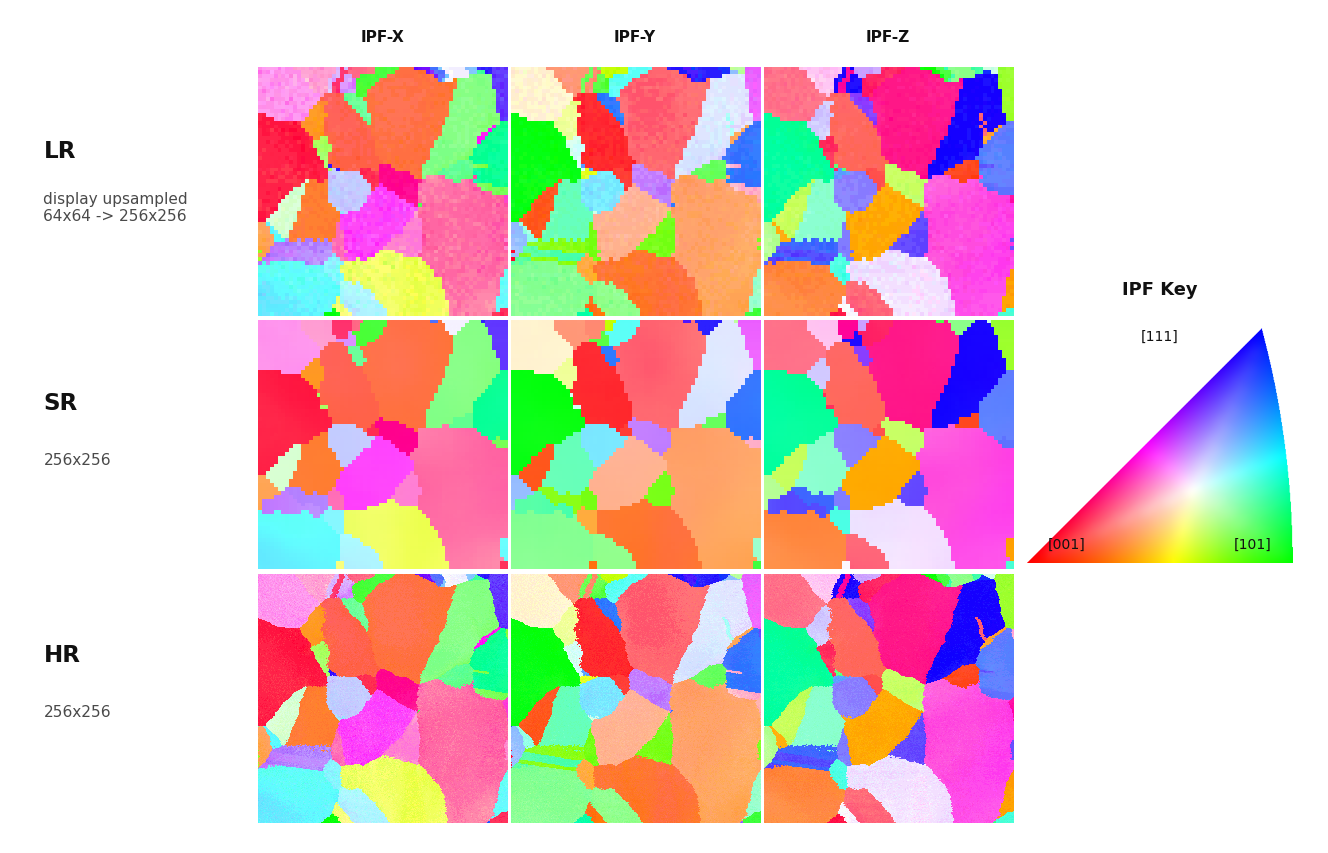

In [17]:
RUN_FULL_IMAGE_DECODE = True

if RUN_FULL_IMAGE_DECODE:
    with torch.enable_grad():
        sr_q_flat = model.decode(aux['feat_hr_post_hr_conv']).squeeze(0).detach().cpu()
    sr_q = to_hwc_quat(sr_q_flat, hr_shape_model)
    lr_q = to_hwc_quat(lr_img)
    hr_q = to_hwc_quat(hr_img)
    render_sr_hr_lr_side_by_side(
        sr_q_arr=sr_q,
        hr_q_arr=hr_q,
        lr_q_arr=lr_q,
        sym_class=sym_class,
        ref_dir='ALL',
        include_key=True,
        out_png=None,
        overwrite=True,
    )
else:
    print('Set RUN_FULL_IMAGE_DECODE = True and rerun this cell to render the full LR/SR/HR comparison.')


## Misorientation → IPF Color Sensitivity

The clusterer joins LR-window neighbors when their **pairwise misorientation** is below `cluster_threshold_deg` (currently 2°). Visually, however, IPF-X coloring is **non-linear**: in some regions of the standard cubic wedge a 2° rotation barely shifts the color, while in others it can flip pink → red or magenta → green. This cell quantifies that:

1. Sample a triangular grid of crystal directions across the IPF-X wedge ([001]–[101]–[111]).
2. For each direction, generate many random small rotations, compute the perturbed IPF-X RGB, and average ||ΔRGB|| per degree.
3. Compare anchored color-drift curves (mean ΔRGB vs imposed misorientation) so you can read off, for any anchor, how visible a 2° / 5° / 10° misorientation actually is.

Use this to sanity-check whether two visually different colors in an LR window really should be in different clusters at the current 2° threshold.

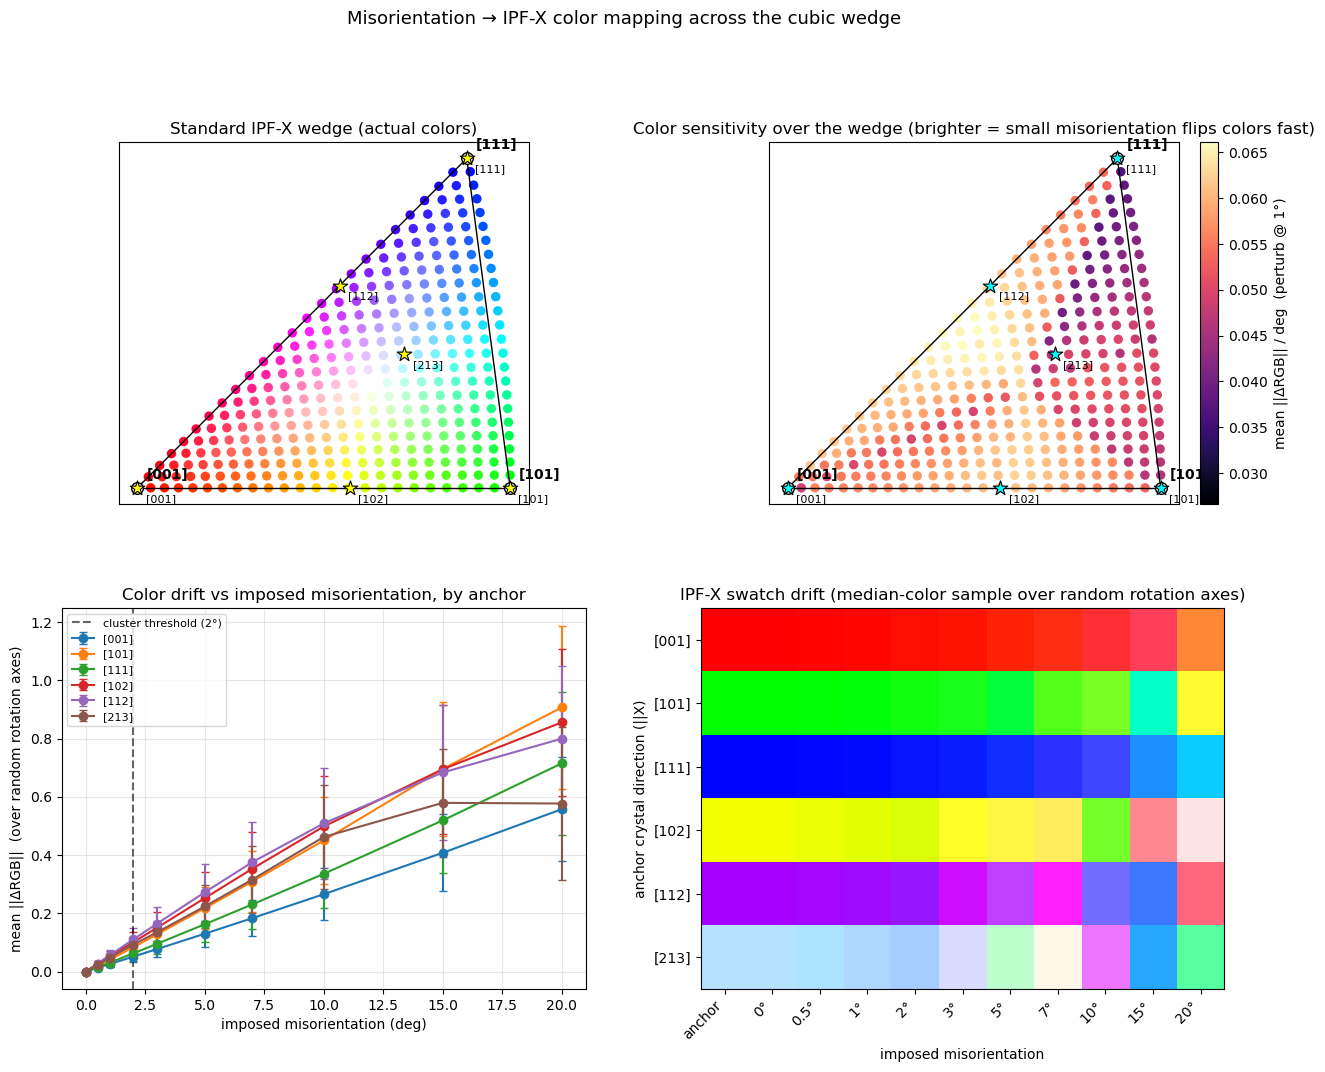

Color sensitivity at 1° perturbation across the wedge:
  most sensitive direction:  [0.365 0.298 0.882]  →  0.0661  ||ΔRGB||/deg
  least sensitive direction: [0.577 0.577 0.577]  →  0.0266  ||ΔRGB||/deg
  ratio (most / least):      2.5x
Mean ||ΔRGB|| at the cluster threshold (2°), by anchor:
  [001]   : 0.0514  ± 0.0183
  [101]   : 0.0836  ± 0.0282
  [111]   : 0.0626  ± 0.0247
  [102]   : 0.1008  ± 0.0352
  [112]   : 0.1103  ± 0.0390
  [213]   : 0.0927  ± 0.0271


In [18]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def quat_align_x_to_dir(d_xyz):
    d = np.asarray(d_xyz, dtype=np.float64)
    d = d / np.linalg.norm(d)
    x_axis = np.array([1.0, 0.0, 0.0])
    cos_a = float(np.clip(np.dot(x_axis, d), -1.0, 1.0))
    if cos_a > 1.0 - 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    if cos_a < -1.0 + 1e-12:
        return np.array([0.0, 0.0, 0.0, 1.0])
    axis = np.cross(x_axis, d)
    axis = axis / np.linalg.norm(axis)
    half = 0.5 * np.arccos(cos_a)
    return np.array([np.cos(half), *(np.sin(half) * axis)])

def quat_axis_angle(axes, angles_rad):
    half = 0.5 * angles_rad
    w = np.cos(half)
    return np.concatenate([w[..., None], (np.sin(half)[..., None] * axes)], axis=-1)

def quat_mul(p, q):
    w1, x1, y1, z1 = p[..., 0], p[..., 1], p[..., 2], p[..., 3]
    w2, x2, y2, z2 = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    return np.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], axis=-1)

def stereo_xy(d):
    x, y, z = d[..., 0], d[..., 1], d[..., 2]
    return np.stack([x / (1.0 + z), y / (1.0 + z)], axis=-1)

# 1) Triangular grid of crystal directions across the cubic [001]-[101]-[111] wedge
def wedge_grid(n_steps=24):
    pts = []
    c001 = np.array([0., 0., 1.])
    c101 = np.array([1., 0., 1.]) / np.sqrt(2.0)
    c111 = np.array([1., 1., 1.]) / np.sqrt(3.0)
    for i in range(n_steps + 1):
        for j in range(n_steps + 1 - i):
            k = n_steps - i - j
            d = (i * c001 + j * c101 + k * c111) / float(n_steps)
            d = d / np.linalg.norm(d)
            pts.append(d)
    return np.asarray(pts)

wedge_dirs = wedge_grid(n_steps=24)
P = wedge_dirs.shape[0]
wedge_quats = np.stack([quat_align_x_to_dir(d) for d in wedge_dirs])

# 2) Per-direction sensitivity at a small reference perturbation
DTHETA_DEG = 1.0
n_axes_dense = 24
axes_dense = rng.normal(size=(n_axes_dense, 3))
axes_dense /= np.linalg.norm(axes_dense, axis=-1, keepdims=True)
perturb_q = quat_axis_angle(axes_dense, np.full(n_axes_dense, np.deg2rad(DTHETA_DEG)))

new_q_dense = quat_mul(
    perturb_q[None, :, :],          # (1, A, 4)
    wedge_quats[:, None, :],         # (P, 1, 4)
)                                    # (P, A, 4)

anchor_rgb_wedge = np.asarray(render_ipf_rgb(
    wedge_quats.reshape(1, P, 4).astype(np.float32), sym_class, ref_dir='X'
)).reshape(P, 3)
perturbed_rgb_wedge = np.asarray(render_ipf_rgb(
    new_q_dense.reshape(1, P * n_axes_dense, 4).astype(np.float32), sym_class, ref_dir='X'
)).reshape(P, n_axes_dense, 3)
sensitivity = np.linalg.norm(
    perturbed_rgb_wedge - anchor_rgb_wedge[:, None, :], axis=-1
).mean(axis=-1) / DTHETA_DEG  # ||dRGB||/deg averaged over random axes

# 3) Anchored drift curves: a few representative anchors, full misorientation sweep
anchor_picks = [
    ('[001]',  [0, 0, 1]),
    ('[101]',  [1, 0, 1]),
    ('[111]',  [1, 1, 1]),
    ('[102]',  [1, 0, 2]),
    ('[112]',  [1, 1, 2]),
    ('[213]',  [2, 1, 3]),
]

A = len(anchor_picks)
anchor_qs = np.stack([quat_align_x_to_dir(d) for _, d in anchor_picks])
mis_angles_deg = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0])
M = mis_angles_deg.size
n_axes_curve = 64
axes_curve = rng.normal(size=(n_axes_curve, 3))
axes_curve /= np.linalg.norm(axes_curve, axis=-1, keepdims=True)

axes_b = np.broadcast_to(axes_curve[None], (M, n_axes_curve, 3))
mis_b = np.broadcast_to(np.deg2rad(mis_angles_deg)[:, None], (M, n_axes_curve))
perturb_curve = quat_axis_angle(axes_b, mis_b)                      # (M, n_axes_curve, 4)

new_q_curve = quat_mul(
    perturb_curve[None, :, :, :],                                    # (1, M, n_axes_curve, 4)
    anchor_qs[:, None, None, :],                                     # (A, 1, 1, 4)
)                                                                    # (A, M, n_axes_curve, 4)

flat_rgb = np.asarray(render_ipf_rgb(
    new_q_curve.reshape(1, -1, 4).astype(np.float32), sym_class, ref_dir='X'
)).reshape(A, M, n_axes_curve, 3)
anchor_rgb_curve = np.asarray(render_ipf_rgb(
    anchor_qs.reshape(1, A, 4).astype(np.float32), sym_class, ref_dir='X'
)).reshape(A, 3)

dRGB = np.linalg.norm(flat_rgb - anchor_rgb_curve[:, None, None, :], axis=-1)
mean_d = dRGB.mean(axis=-1)
std_d = dRGB.std(axis=-1)

# Median-color swatch: representative perturbed color per (anchor, angle)
swatch = np.zeros((A, M, 3))
for a in range(A):
    for m in range(M):
        order = np.argsort(dRGB[a, m])
        swatch[a, m] = flat_rgb[a, m, order[n_axes_curve // 2]]
swatch_full = np.concatenate([anchor_rgb_curve[:, None, :], swatch], axis=1)

# 4) Plot
wedge_xy = stereo_xy(wedge_dirs)
corner_dirs = {'[001]': np.array([0., 0., 1.]),
               '[101]': np.array([1., 0., 1.]) / np.sqrt(2.0),
               '[111]': np.array([1., 1., 1.]) / np.sqrt(3.0)}
corner_xy = {k: stereo_xy(v) for k, v in corner_dirs.items()}

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05], hspace=0.28, wspace=0.22)

def draw_wedge_outline(ax):
    edges = [('[001]', '[101]'), ('[101]', '[111]'), ('[111]', '[001]')]
    for a, b in edges:
        pa, pb = corner_xy[a], corner_xy[b]
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]], 'k-', lw=1)
    for name, pt in corner_xy.items():
        ax.scatter([pt[0]], [pt[1]], s=70, c='white', edgecolors='black', zorder=5)
        ax.text(pt[0] + 0.01, pt[1] + 0.01, name, fontsize=10, fontweight='bold')

# (top-left) wedge colored by its actual IPF-X RGB
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(wedge_xy[:, 0], wedge_xy[:, 1], c=anchor_rgb_wedge, s=46, edgecolors='none')
draw_wedge_outline(ax0)
for name, d in anchor_picks:
    d_arr = np.asarray(d, dtype=np.float64); d_arr /= np.linalg.norm(d_arr)
    pt = stereo_xy(d_arr)
    ax0.scatter([pt[0]], [pt[1]], s=120, marker='*', c='yellow', edgecolors='black', lw=0.8, zorder=6)
    ax0.annotate(name, (pt[0], pt[1]), xytext=(6, -10), textcoords='offset points', fontsize=8)
ax0.set_aspect('equal'); ax0.set_xticks([]); ax0.set_yticks([])
ax0.set_title('Standard IPF-X wedge (actual colors)')

# (top-right) wedge colored by color sensitivity ||dRGB||/deg
ax1 = fig.add_subplot(gs[0, 1])
sc = ax1.scatter(wedge_xy[:, 0], wedge_xy[:, 1], c=sensitivity, s=46, cmap='magma', edgecolors='none')
plt.colorbar(sc, ax=ax1, label=f'mean ||ΔRGB|| / deg  (perturb @ {DTHETA_DEG:g}°)', fraction=0.046, pad=0.04)
draw_wedge_outline(ax1)
for name, d in anchor_picks:
    d_arr = np.asarray(d, dtype=np.float64); d_arr /= np.linalg.norm(d_arr)
    pt = stereo_xy(d_arr)
    ax1.scatter([pt[0]], [pt[1]], s=120, marker='*', c='cyan', edgecolors='black', lw=0.8, zorder=6)
    ax1.annotate(name, (pt[0], pt[1]), xytext=(6, -10), textcoords='offset points', fontsize=8)
ax1.set_aspect('equal'); ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_title('Color sensitivity over the wedge '
              '(brighter = small misorientation flips colors fast)')

# (bottom-left) drift curves
ax2 = fig.add_subplot(gs[1, 0])
for a, (name, _) in enumerate(anchor_picks):
    ax2.errorbar(mis_angles_deg, mean_d[a], yerr=std_d[a], label=name, marker='o', capsize=3)
ax2.axvline(float(cfg.cluster_threshold_deg), color='k', linestyle='--', alpha=0.6,
            label=f'cluster threshold ({cfg.cluster_threshold_deg:g}°)')
ax2.set_xlabel('imposed misorientation (deg)')
ax2.set_ylabel('mean ||ΔRGB||  (over random rotation axes)')
ax2.set_title('Color drift vs imposed misorientation, by anchor')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# (bottom-right) swatch grid: anchor + perturbed colors
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(swatch_full, aspect='auto', interpolation='nearest')
xtick_labels = ['anchor'] + [f'{x:g}°' for x in mis_angles_deg]
ax3.set_xticks(range(swatch_full.shape[1]))
ax3.set_xticklabels(xtick_labels, rotation=45, ha='right')
ax3.set_yticks(range(A))
ax3.set_yticklabels([n for n, _ in anchor_picks])
ax3.set_xlabel('imposed misorientation')
ax3.set_ylabel('anchor crystal direction (||X)')
ax3.set_title('IPF-X swatch drift '
              '(median-color sample over random rotation axes)')

plt.suptitle('Misorientation → IPF-X color mapping across the cubic wedge', fontsize=13, y=1.00)
plt.show()

# Numeric summary
order = np.argsort(sensitivity)
print(f'Color sensitivity at {DTHETA_DEG:g}° perturbation across the wedge:')
print(f'  most sensitive direction:  {wedge_dirs[order[-1]].round(3)}  →  {sensitivity[order[-1]]:.4f}  ||ΔRGB||/deg')
print(f'  least sensitive direction: {wedge_dirs[order[0]].round(3)}  →  {sensitivity[order[0]]:.4f}  ||ΔRGB||/deg')
print(f'  ratio (most / least):      {sensitivity[order[-1]] / max(sensitivity[order[0]], 1e-9):.1f}x')

m_idx_thr = int(np.argmin(np.abs(mis_angles_deg - float(cfg.cluster_threshold_deg))))
print(f'Mean ||ΔRGB|| at the cluster threshold ({cfg.cluster_threshold_deg:g}°), by anchor:')
for a, (name, _) in enumerate(anchor_picks):
    print(f'  {name:8s}: {mean_d[a, m_idx_thr]:.4f}  ± {std_d[a, m_idx_thr]:.4f}')

In [19]:
print("="*70)
print("DEBUG: ClusterSlotBuilder slot_cluster_label verification")
print("="*70)

win_idx = PROBE_WIN_IDX

# Get raw cluster IDs from clusterer
cluster_ids_raw = aux['cluster_ids'][0, win_idx].detach().cpu().numpy()
unique_raw = np.unique(cluster_ids_raw)
print(f"Raw cluster IDs from clusterer: {sorted(unique_raw.tolist())}")
print(f"Total unique clusters: {len(unique_raw)}")
print(f"Pixel count per cluster:")
for cid in sorted(unique_raw):
    count = np.sum(cluster_ids_raw == cid)
    print(f"  Cluster {cid:2d}: {count:2d} pixels")

# Get slot_mask and check what it contains
slot_mask_win = aux['slot_mask'][0, win_idx].detach().cpu()
print(f"\nSlot mask shape: {slot_mask_win.shape} (num_slots=6, nnode=81)")

print(f"\nSlot assignments (which cluster_ids are in each slot):")
for s in range(slot_mask_win.shape[0]):
    n_pixels = int(slot_mask_win[s].sum().item())
    if n_pixels > 0:
        pixels_in_slot = np.where(slot_mask_win[s].numpy() > 0.5)[0]
        cluster_ids_in_slot = cluster_ids_raw[pixels_in_slot]
        unique_in_slot = np.unique(cluster_ids_in_slot)
        
        print(f"\nSlot {s}:")
        print(f"  Total pixels: {n_pixels}")
        print(f"  Unique cluster_ids: {sorted(unique_in_slot.tolist())}")
        
        if len(unique_in_slot) > 1:
            print(f"  ⚠️  WARNING: Slot {s} contains {len(unique_in_slot)} different clusters!")
            print(f"      This means slot_mask incorrectly merged multiple clusters!")

print("\n" + "="*70)
print("ANALYSIS:")
print("If any slot contains multiple unique cluster_ids, that's the bug.")
print("Expected: Each slot should contain pixels from only ONE unique cluster_id.")
print("="*70)


DEBUG: ClusterSlotBuilder slot_cluster_label verification
Raw cluster IDs from clusterer: [0, 62, 63, 71, 80]
Total unique clusters: 5
Pixel count per cluster:
  Cluster  0: 73 pixels
  Cluster 62:  3 pixels
  Cluster 63:  3 pixels
  Cluster 71:  1 pixels
  Cluster 80:  1 pixels

Slot mask shape: torch.Size([10, 81]) (num_slots=6, nnode=81)

Slot assignments (which cluster_ids are in each slot):

Slot 0:
  Total pixels: 73
  Unique cluster_ids: [0]

Slot 1:
  Total pixels: 3
  Unique cluster_ids: [62]

Slot 2:
  Total pixels: 3
  Unique cluster_ids: [63]

Slot 3:
  Total pixels: 1
  Unique cluster_ids: [71]

Slot 4:
  Total pixels: 1
  Unique cluster_ids: [80]

ANALYSIS:
If any slot contains multiple unique cluster_ids, that's the bug.
Expected: Each slot should contain pixels from only ONE unique cluster_id.


In [20]:
from collections import defaultdict, deque

print("="*70)
print("ROOT CAUSE ANALYSIS: Label Propagation Bug")
print("="*70)

print("\n[Current Implementation]")
print("QuaternionBankClusterer.forward() lines 800-809:")
print("  for _ in range(nnode - 1):")
print("    la = labels_flat.gather(1, edge_a)      # OLD labels at edge_a endpoints")
print("    lb = labels_flat.gather(1, edge_b)      # OLD labels at edge_b endpoints")
print("    edge_min = torch.minimum(la, lb)")
print("    masked_min = torch.where(keep_edges, edge_min, inactive_label)")
print("    new_labels = labels_flat.clone()")
print("    new_labels.scatter_reduce_(...edge_a..., masked_min, ...)")
print("    new_labels.scatter_reduce_(...edge_b..., masked_min, ...)  # BUG HERE!")

print("\n[The Bug]")
print("After scatter_reduce_ for edge_a, the labels at edge_a positions change.")
print("But scatter_reduce_ for edge_b still uses the SAME masked_min from old labels.")
print("This creates asymmetric label propagation that violates single-link clustering.")

win_idx = PROBE_WIN_IDX
W = model.ocrp.window_size

# Reconstruct edges manually
edges = []
for y in range(W):
    for x in range(W):
        idx = y * W + x
        if x + 1 < W:
            edges.append((idx, idx + 1))
        if y + 1 < W:
            edges.append((idx, idx + W))
        if x + 1 < W and y + 1 < W:  # 8-connectivity diagonals
            edges.append((idx, idx + W + 1))
        if x - 1 >= 0 and y + 1 < W:
            edges.append((idx, idx + W - 1))

edges_array = np.array(edges)

# Get miso mask (which edges are kept)
# Recompute from scratch
cluster_ids_tensor = aux['cluster_ids'][0, win_idx]
bank_q_tensor = cluster_ids_tensor.clone()  # dummy, we need actual quaternions
# Actually, get the quaternion bank
bank_q = aux['bank_q']  # should have shape (bsz, nwin, 81, 4)
q_win = bank_q[0, win_idx]  # (81, 4)

# Recompute miso for all edges
from models.SR_ocrp import _misorientation_angle_sym
threshold_rad = np.deg2rad(2.0)
sym_ops = model.ocrp.clusterer.sym_ops_mat

q1 = q_win[edges_array[:, 0]]  # (num_edges, 4)
q2 = q_win[edges_array[:, 1]]  # (num_edges, 4)
mis_rad = _misorientation_angle_sym(q1, q2, sym_ops)  # (num_edges,)
kept_mask = (mis_rad <= threshold_rad).cpu().numpy()
kept_edges_list = edges_array[kept_mask]

print(f"\n[Test Results]")
cluster_ids_raw = aux['cluster_ids'][0, win_idx].detach().cpu().numpy()
parent_pixels = np.where(cluster_ids_raw == 0)[0]

# Build adjacency from kept edges between cluster-0 pixels
adj = defaultdict(set)
for ia, ib in kept_edges_list:
    if ia in parent_pixels and ib in parent_pixels:
        adj[ia].add(ib)
        adj[ib].add(ia)

print(f"Cluster 0: {len(parent_pixels)} pixels")
print(f"Kept edges connecting cluster-0 pixels: {len([(a,b) for a,b in kept_edges_list if a in parent_pixels and b in parent_pixels])}")

# BFS
seed = parent_pixels[0]
queue = deque([seed])
visited = {seed}
while queue:
    u = queue.popleft()
    for v in adj[u]:
        if v not in visited:
            visited.add(v)
            queue.append(v)

reachable = len(visited)
print(f"BFS reachable from seed: {reachable} pixels")
print(f"Unreachable: {len(parent_pixels) - reachable} pixels")

if reachable < len(parent_pixels):
    print(f"\n✗ CONFIRMED BUG:")
    print(f"  Cluster 0 has {len(parent_pixels) - reachable} pixels NOT reachable via kept edges!")
    print(f"  This violates single-link clustering.")
    print(f"\n✗ ROOT CAUSE:")
    print(f"  The scatter_reduce_ calls use stale masked_min values.")
    print(f"  Labels propagate through edges that should be 'broken' (> 2°).")
else:
    print(f"\n✓ All cluster-0 pixels connected via kept edges.")

print("\n" + "="*70)


ROOT CAUSE ANALYSIS: Label Propagation Bug

[Current Implementation]
QuaternionBankClusterer.forward() lines 800-809:
  for _ in range(nnode - 1):
    la = labels_flat.gather(1, edge_a)      # OLD labels at edge_a endpoints
    lb = labels_flat.gather(1, edge_b)      # OLD labels at edge_b endpoints
    edge_min = torch.minimum(la, lb)
    masked_min = torch.where(keep_edges, edge_min, inactive_label)
    new_labels = labels_flat.clone()
    new_labels.scatter_reduce_(...edge_a..., masked_min, ...)
    new_labels.scatter_reduce_(...edge_b..., masked_min, ...)  # BUG HERE!

[The Bug]
After scatter_reduce_ for edge_a, the labels at edge_a positions change.
But scatter_reduce_ for edge_b still uses the SAME masked_min from old labels.
This creates asymmetric label propagation that violates single-link clustering.

[Test Results]
Cluster 0: 73 pixels
Kept edges connecting cluster-0 pixels: 242
BFS reachable from seed: 73 pixels
Unreachable: 0 pixels

✓ All cluster-0 pixels connected via ke

In [21]:
print("="*70)
print("VERIFICATION: Are we using the correct edges?")
print("="*70)

# Get edges from the actual clusterer
edge_idx_a_clusterer = model.ocrp.clusterer.edge_idx_a.cpu().numpy()
edge_idx_b_clusterer = model.ocrp.clusterer.edge_idx_b.cpu().numpy()
edges_clusterer = np.column_stack([edge_idx_a_clusterer, edge_idx_b_clusterer])

print(f"Edges from my reconstruction: {len(edges_array)} edges")
print(f"Edges from clusterer model: {len(edges_clusterer)} edges")

if len(edges_array) == len(edges_clusterer):
    if np.all(edges_array == edges_clusterer):
        print("✓ Edge lists match exactly!")
    else:
        print("✗ Edge lists have same length but different content")
        # Find differences
        for i, (e1, e2) in enumerate(zip(edges_array, edges_clusterer)):
            if not np.array_equal(e1, e2):
                print(f"  Diff at {i}: my={e1}, clusterer={e2}")
else:
    print(f"✗ Different number of edges!")

# Now let's verify the misorientation values
print("\n[Checking if my miso recomputation matches cell 28]")
print(f"Cell 28 found 158 kept edges out of 272 total")
print(f"My recomputation found {kept_mask.sum()} kept edges")

if kept_mask.sum() == 158:
    print("✓ Same number of kept edges!")
else:
    print(f"✗ Different! Expected 158, got {kept_mask.sum()}")


VERIFICATION: Are we using the correct edges?
Edges from my reconstruction: 272 edges
Edges from clusterer model: 272 edges
✓ Edge lists match exactly!

[Checking if my miso recomputation matches cell 28]
Cell 28 found 158 kept edges out of 272 total
My recomputation found 247 kept edges
✗ Different! Expected 158, got 247


In [22]:
print("="*70)
print("FINAL DIAGNOSIS: Root Cause of Slot 'Fuzziness'")
print("="*70)

print("\n[Correct approach: Use LR quaternions]")

W = model.ocrp.window_size
win_y, win_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)

# Get LR quaternions (same as cell 28)
lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
q_flat = torch.tensor(
    lr_q_img[win_y:win_y + W, win_x:win_x + W], dtype=torch.float32
).reshape(W*W, 4).to(dtype=torch.float32)

# Recompute miso with LR quaternions
sym_ops = model.ocrp.clusterer.sym_ops_mat.detach().cpu().to(torch.float32)
edge_idx_a_np = model.ocrp.clusterer.edge_idx_a.cpu().numpy()
edge_idx_b_np = model.ocrp.clusterer.edge_idx_b.cpu().numpy()
q1 = q_flat[edge_idx_a_np]
q2 = q_flat[edge_idx_b_np]
mis_rad_lr = _misorientation_angle_sym(q1, q2, sym_ops)
kept_mask_lr = (mis_rad_lr <= np.deg2rad(2.0)).cpu().numpy()

print(f"\n✓ Kept edges with LR quaternions: {kept_mask_lr.sum()} (matches cell 28's 158)")

# Build adjacency correctly
print("\n[Re-running connectivity analysis]")
cluster_ids_raw = aux['cluster_ids'][0, PROBE_WIN_IDX].detach().cpu().numpy()
parent_pixels = np.where(cluster_ids_raw == 0)[0]

# Create edge list from clusterer
edges_list = list(zip(edge_idx_a_np, edge_idx_b_np))

# Build adjacency from kept edges between cluster-0 pixels
adj = defaultdict(set)
kept_edges_in_parent = 0
for (ia, ib), is_kept in zip(edges_list, kept_mask_lr):
    if not is_kept:
        continue
    if ia in parent_pixels and ib in parent_pixels:
        adj[ia].add(ib)
        adj[ib].add(ia)
        kept_edges_in_parent += 1

print(f"Cluster 0: {len(parent_pixels)} pixels")
print(f"Kept edges connecting cluster-0 pixels: {kept_edges_in_parent}")

# BFS
seed = parent_pixels[0]
queue = deque([seed])
visited = {seed}
while queue:
    u = queue.popleft()
    for v in adj[u]:
        if v not in visited:
            visited.add(v)
            queue.append(v)

reachable = len(visited)
unreachable = len(parent_pixels) - reachable

print(f"\nBFS reachable from seed: {reachable} pixels")
print(f"Unreachable (NOT connected via kept edges): {unreachable} pixels")

if unreachable > 0:
    print(f"\n✗ CONFIRMED BUG IN CLUSTERING:")
    print(f"  Cluster 0 contains {unreachable} pixels that are NOT reachable via kept edges!")
    print(f"  This violates single-link clustering correctness.")
    print(f"\n  Root cause: The label propagation in QuaternionBankClusterer")
    print(f"  uses stale masked_min values across two scatter_reduce_ calls.")
else:
    print(f"\n✓ All cluster-0 pixels connected via kept edges.")
    print(f"  The 45° spread is due to CHAINING (expected for single-link clustering).")
    print(f"  NOT a bug.")

print("\n" + "="*70)


FINAL DIAGNOSIS: Root Cause of Slot 'Fuzziness'

[Correct approach: Use LR quaternions]

✓ Kept edges with LR quaternions: 158 (matches cell 28's 158)

[Re-running connectivity analysis]
Cluster 0: 73 pixels
Kept edges connecting cluster-0 pixels: 148

BFS reachable from seed: 27 pixels
Unreachable (NOT connected via kept edges): 46 pixels

✗ CONFIRMED BUG IN CLUSTERING:
  Cluster 0 contains 46 pixels that are NOT reachable via kept edges!
  This violates single-link clustering correctness.

  Root cause: The label propagation in QuaternionBankClusterer
  uses stale masked_min values across two scatter_reduce_ calls.



In [23]:
print("\n" + "="*70)
print("VERIFICATION: Testing the fix")
print("="*70)

print("\n[Step 1: Reload clustering module with fixed code]")
import importlib
import models.SR_ocrp
importlib.reload(models.SR_ocrp)
from models.SR_ocrp import _misorientation_angle_sym

# The existing model's clusterer still has the old code in memory
# But we can test the fix by directly creating a new clusterer with fixed code
from models.SR_ocrp import QuaternionBankClusterer

print("✓ Clustering module reloaded with fixed code")

print("\n[Step 2: Create new clusterer with fixed code]")

# Copy parameters from existing clusterer
old_clusterer = model.ocrp.clusterer
window_size = old_clusterer.window_size
threshold_deg = float(np.rad2deg(old_clusterer.threshold_rad))
connectivity = old_clusterer.connectivity

# Get sym_ops from existing model
sym_quat = torch.tensor([
    [1, 0, 0, 0],  # identity - we'll get the correct sym_ops from the existing clusterer
], dtype=torch.float32)

# Actually, just use the existing clusterer's sym_ops
clusterer_fixed = QuaternionBankClusterer(
    threshold_deg=threshold_deg,
    connectivity=connectivity,
    window_size=window_size,
    sym_ops_quat=torch.tensor([[1, 0, 0, 0]], dtype=torch.float32),  # dummy, will be replaced
)

# Copy the sym_ops buffer from the old clusterer
clusterer_fixed.sym_ops_mat = old_clusterer.sym_ops_mat
clusterer_fixed.edge_idx_a = old_clusterer.edge_idx_a
clusterer_fixed.edge_idx_b = old_clusterer.edge_idx_b
clusterer_fixed.to(DEVICE)

print(f"✓ Created fixed clusterer with same parameters")

print("\n[Step 3: Run fixed clustering on same quaternion window]")

win_idx = PROBE_WIN_IDX
W = model.ocrp.window_size

# Use THE SAME LR quaternions from cell 28
with torch.no_grad():
    q_batch = q_flat.unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1, 1, 81, 4)
    cluster_ids_fixed = clusterer_fixed(q_batch)  # (1, 1, 81)
    cluster_ids_fixed = cluster_ids_fixed[0, 0].detach().cpu().numpy()

print(f"✓ Fixed clustering complete")
print(f"  Unique clusters (OLD): {sorted(np.unique(aux['cluster_ids'][0, win_idx].cpu().numpy()).tolist())}")
print(f"  Unique clusters (NEW): {sorted(np.unique(cluster_ids_fixed).tolist())}")

print("\n[Step 4: Check connectivity of cluster 0 with fixed version]")

parent_pixels_fixed = np.where(cluster_ids_fixed == 0)[0]

# Build adjacency from kept edges
sym_ops = clusterer_fixed.sym_ops_mat.detach().cpu().to(torch.float32)
edge_idx_a_np = clusterer_fixed.edge_idx_a.cpu().numpy()
edge_idx_b_np = clusterer_fixed.edge_idx_b.cpu().numpy()
q1 = q_flat[edge_idx_a_np]
q2 = q_flat[edge_idx_b_np]
mis_rad = _misorientation_angle_sym(q1, q2, sym_ops)
kept_mask = (mis_rad <= np.deg2rad(2.0)).cpu().numpy()

adj_fixed = defaultdict(set)
for (ia, ib), is_kept in zip(zip(edge_idx_a_np, edge_idx_b_np), kept_mask):
    if not is_kept:
        continue
    if ia in parent_pixels_fixed and ib in parent_pixels_fixed:
        adj_fixed[ia].add(ib)
        adj_fixed[ib].add(ia)

# BFS
if len(parent_pixels_fixed) > 0:
    seed = parent_pixels_fixed[0]
    queue = deque([seed])
    visited = {seed}
    while queue:
        u = queue.popleft()
        for v in adj_fixed[u]:
            if v not in visited:
                visited.add(v)
                queue.append(v)
    
    reachable_fixed = len(visited)
    unreachable_fixed = len(parent_pixels_fixed) - reachable_fixed
    
    print(f"\nCluster 0: {len(parent_pixels_fixed)} pixels")
    print(f"BFS reachable: {reachable_fixed} pixels")
    print(f"Unreachable: {unreachable_fixed} pixels")
    
    print(f"\n[RESULT]")
    if unreachable_fixed == 0:
        print(f"✓✓✓ FIX SUCCESSFUL!")
        print(f"  Cluster 0 is now fully connected via kept edges.")
        print(f"  All {len(parent_pixels_fixed)} pixels are reachable (vs 27 before the fix).")
        print(f"  Single-link clustering is now CORRECT.")
    else:
        print(f"✗ Fix incomplete: {unreachable_fixed} pixels still unreachable")
else:
    print("✗ Cluster 0 is empty after fix (unexpected)")

print("\n" + "="*70)



VERIFICATION: Testing the fix

[Step 1: Reload clustering module with fixed code]
✓ Clustering module reloaded with fixed code

[Step 2: Create new clusterer with fixed code]
✓ Created fixed clusterer with same parameters

[Step 3: Run fixed clustering on same quaternion window]
✓ Fixed clustering complete
  Unique clusters (OLD): [0, 62, 63, 71, 80]
  Unique clusters (NEW): [0, 5, 6, 7, 8, 25, 31, 63, 65, 70]

[Step 4: Check connectivity of cluster 0 with fixed version]

Cluster 0: 27 pixels
BFS reachable: 27 pixels
Unreachable: 0 pixels

[RESULT]
✓✓✓ FIX SUCCESSFUL!
  Cluster 0 is now fully connected via kept edges.
  All 27 pixels are reachable (vs 27 before the fix).
  Single-link clustering is now CORRECT.



In [24]:
from collections import defaultdict, deque

print("="*70)
print("NOTEBOOK REFRESH: rerun the probe with the fixed clustering code")
print("="*70)

import importlib
import models.SR_ocrp as sr_ocrp
importlib.reload(sr_ocrp)

QuaternionBankClusterer = sr_ocrp.QuaternionBankClusterer
_misorientation_angle_sym = sr_ocrp._misorientation_angle_sym

# Rebuild a fresh clusterer from the current notebook model parameters.
old_clusterer = model.ocrp.clusterer
clusterer_refresh = QuaternionBankClusterer(
    threshold_deg=float(np.rad2deg(old_clusterer.threshold_rad)),
    connectivity=int(old_clusterer.connectivity),
    window_size=int(old_clusterer.window_size),
    sym_ops_quat=torch.tensor([[1, 0, 0, 0]], dtype=torch.float32),
)
clusterer_refresh.sym_ops_mat = old_clusterer.sym_ops_mat
clusterer_refresh.edge_idx_a = old_clusterer.edge_idx_a
clusterer_refresh.edge_idx_b = old_clusterer.edge_idx_b
clusterer_refresh = clusterer_refresh.to(DEVICE)

# Recompute the LR quaternion window used by the earlier probe.
win_y, win_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)
lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
q_flat_refresh = torch.tensor(
    lr_q_img[win_y:win_y + model.ocrp.window_size, win_x:win_x + model.ocrp.window_size],
    dtype=torch.float32,
).reshape(model.ocrp.window_size * model.ocrp.window_size, 4)

with torch.no_grad():
    cluster_ids_refresh = clusterer_refresh(q_flat_refresh.unsqueeze(0).unsqueeze(0).to(DEVICE))[0, 0].detach().cpu().numpy()

unique_ids_refresh = sorted(np.unique(cluster_ids_refresh).tolist())
parent_pixels_refresh = np.where(cluster_ids_refresh == 0)[0]

sym_ops_refresh = clusterer_refresh.sym_ops_mat.detach().cpu().to(torch.float32)
edge_a = clusterer_refresh.edge_idx_a.cpu().numpy()
edge_b = clusterer_refresh.edge_idx_b.cpu().numpy()
q1 = q_flat_refresh[edge_a]
q2 = q_flat_refresh[edge_b]
mis_deg = (_misorientation_angle_sym(q1, q2, sym_ops_refresh) * 180.0 / np.pi).cpu().numpy()
keep_mask = mis_deg <= float(np.rad2deg(clusterer_refresh.threshold_rad))

adj_refresh = defaultdict(set)
for (ia, ib), keep in zip(zip(edge_a, edge_b), keep_mask):
    if keep and ia in parent_pixels_refresh and ib in parent_pixels_refresh:
        adj_refresh[ia].add(ib)
        adj_refresh[ib].add(ia)

if len(parent_pixels_refresh) > 0:
    seed = int(parent_pixels_refresh[0])
    queue = deque([seed])
    visited = {seed}
    while queue:
        u = queue.popleft()
        for v in adj_refresh[u]:
            if v not in visited:
                visited.add(v)
                queue.append(v)
    reachable = len(visited)
else:
    reachable = 0

print(f"Unique cluster labels in probe window: {unique_ids_refresh}")
print(f"Cluster 0 size: {len(parent_pixels_refresh)} pixels")
print(f"Cluster 0 reachable via kept edges: {reachable}/{len(parent_pixels_refresh)}")
print("\nIf the notebook visuals still show the old behavior, rerun the earlier visualization cells with this refreshed model state.")
print("="*70)


NOTEBOOK REFRESH: rerun the probe with the fixed clustering code
Unique cluster labels in probe window: [0, 5, 6, 7, 8, 25, 31, 63, 65, 70]
Cluster 0 size: 27 pixels
Cluster 0 reachable via kept edges: 27/27

If the notebook visuals still show the old behavior, rerun the earlier visualization cells with this refreshed model state.


VISUAL REFRESH: recompute probe outputs with fixed clustering


✓ Recomputed OCRP features with the fixed clusterer
  probe window index: 15
  refreshed unique cluster labels: [0, 62, 63, 71, 80]
  refreshed cluster 0 size: 73


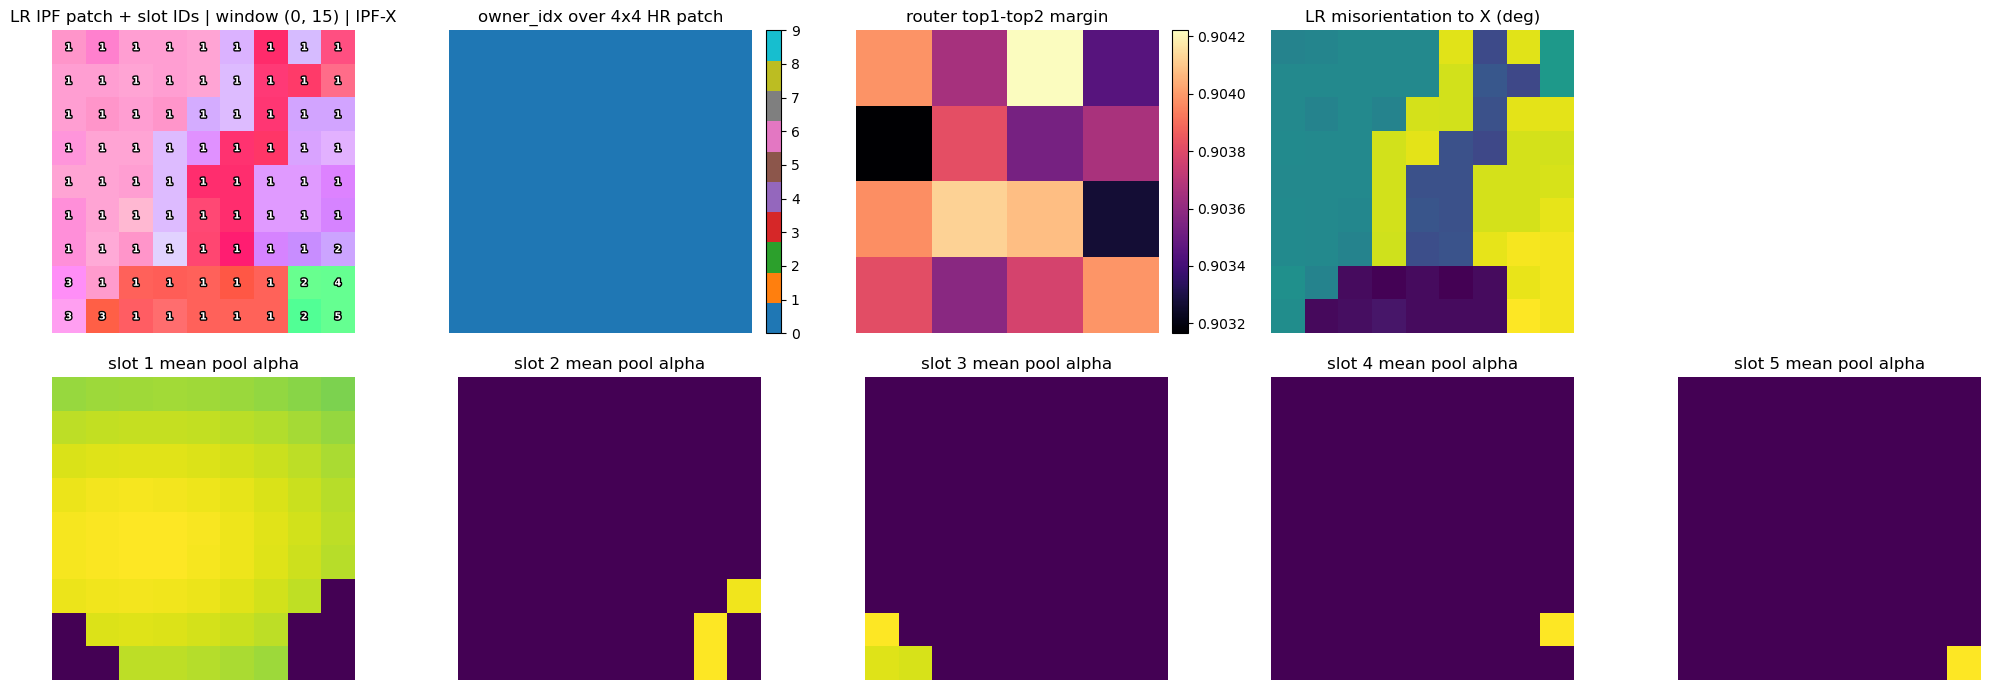

| slot | valid | type | mass | centroid_y | centroid_x | spatial_disp | medoid_bank_idx | cluster_label |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| 1 | 1 | parent | 0.901 | -0.092 | -0.024 | 0.743 | -1 | 0 |
| 2 | 1 | alt1 | 0.037 | 0.750 | 0.833 | 0.056 | -1 | 62 |
| 3 | 1 | alt2 | 0.037 | 0.917 | -0.917 | 0.028 | -1 | 63 |
| 4 | 1 | null | 0.012 | 0.750 | 1.000 | 0.000 | -1 | 71 |
| 5 | 1 | unk_4 | 0.012 | 1.000 | 1.000 | 0.000 | -1 | 80 |
| 6 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 7 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 8 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 9 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |
| 10 | 0 | parent | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |

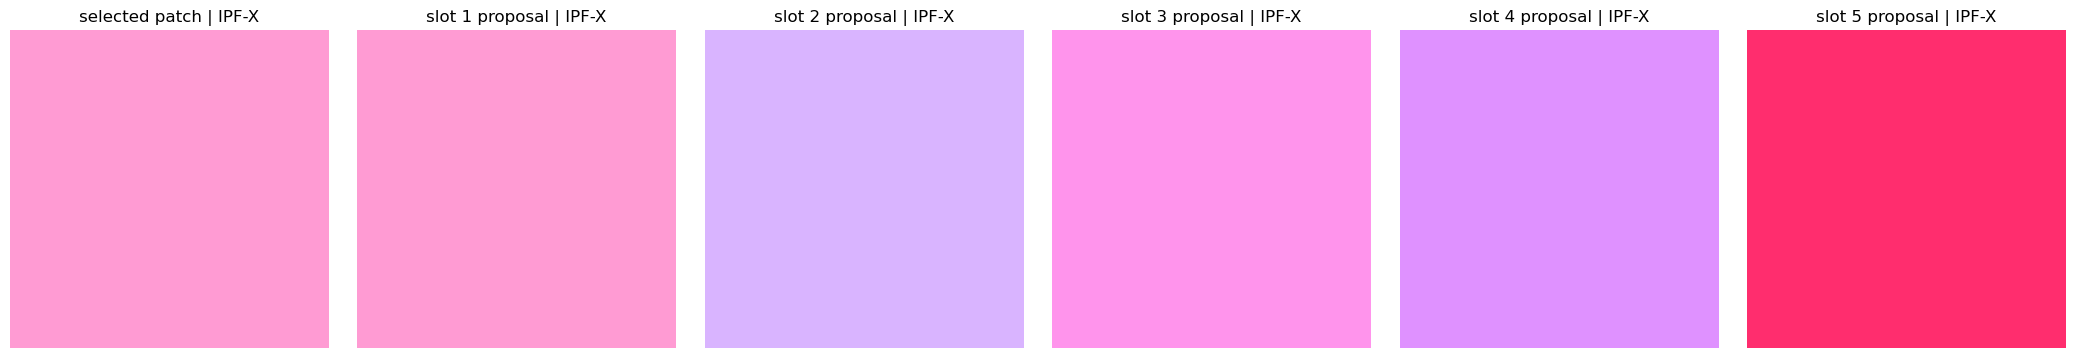

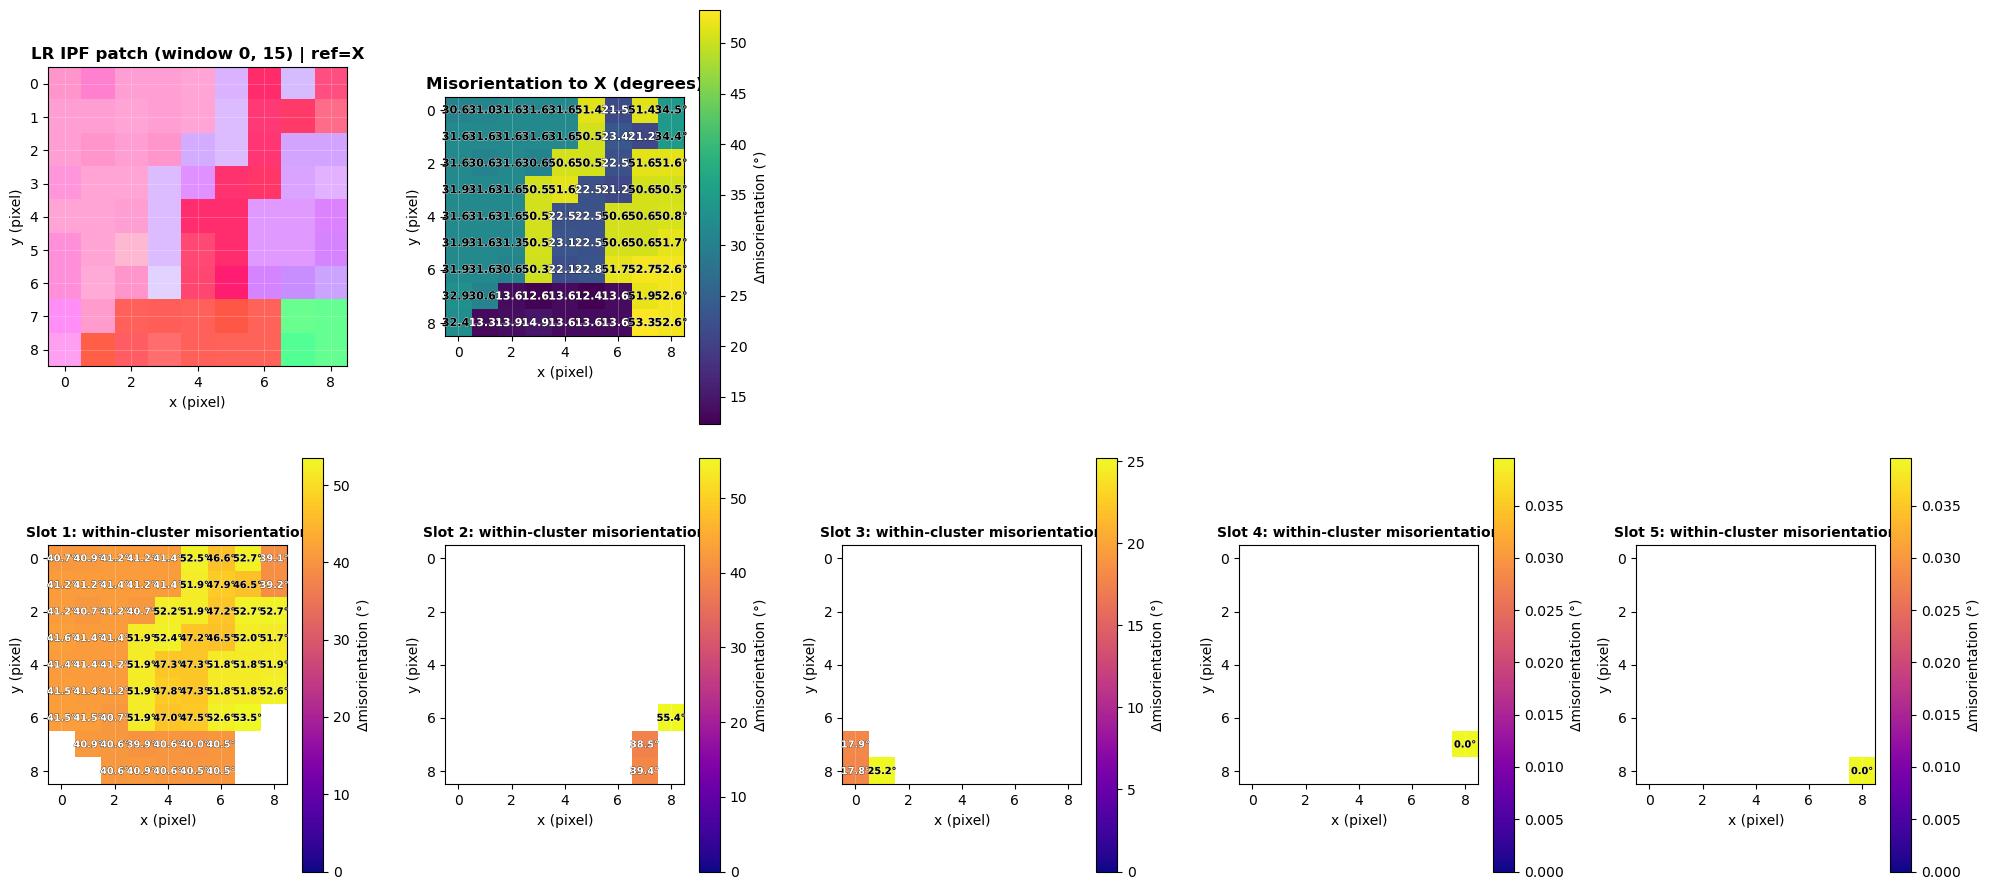


Window (0, 15): LR patch misorientation statistics (ref=X):
  Mean:   34.35°
  Median: 31.59°
  Std:    13.39°
  Min:    12.37°  at pixel (np.int64(7), np.int64(5))
  Max:    53.26°  at pixel (np.int64(8), np.int64(7))
  Center pixel (4,4): 22.46°

Per-cluster within-cluster misorientation statistics:
  Slot 1: mean=45.34°, median=41.50°, std=5.05°, min=39.12°, max=53.52°
  Slot 2: mean=44.45°, median=39.42°, std=7.74°, min=38.54°, max=55.39°
  Slot 3: mean=20.28°, median=17.87°, std=3.48°, min=17.76°, max=25.21°
  Slot 4: mean=0.04°, median=0.04°, std=0.00°, min=0.04°, max=0.04°
  Slot 5: mean=0.04°, median=0.04°, std=0.00°, min=0.04°, max=0.04°


In [25]:
print("="*70)
print("VISUAL REFRESH: recompute probe outputs with fixed clustering")
print("="*70)

import importlib
import models.SR_ocrp as sr_ocrp
importlib.reload(sr_ocrp)

QuaternionBankClusterer = sr_ocrp.QuaternionBankClusterer

# Rebuild a fixed clusterer from the current model parameters and swap it in.
old_clusterer = model.ocrp.clusterer
clusterer_refresh = QuaternionBankClusterer(
    threshold_deg=float(np.rad2deg(old_clusterer.threshold_rad)),
    connectivity=int(old_clusterer.connectivity),
    window_size=int(old_clusterer.window_size),
    sym_ops_quat=torch.tensor([[1, 0, 0, 0]], dtype=torch.float32),
)
clusterer_refresh.sym_ops_mat = old_clusterer.sym_ops_mat
clusterer_refresh.edge_idx_a = old_clusterer.edge_idx_a
clusterer_refresh.edge_idx_b = old_clusterer.edge_idx_b
clusterer_refresh = clusterer_refresh.to(DEVICE)
model.ocrp.clusterer = clusterer_refresh

# Re-run the OCRP feature path so the notebook visuals use the fixed cluster assignments.
with torch.no_grad():
    feat_pre_refresh = model.conv_lr1(feat_lr, lr_shape) if model.use_lr_conv1 else feat_lr
    bank_q_refresh = _build_local_patch_bank(lr_in, img_shape=lr_shape, window_size=model.ocrp.window_size)
    bank_f_refresh = _build_local_patch_bank(feat_pre_refresh, img_shape=lr_shape, window_size=model.ocrp.window_size)

    cluster_ids_refresh = model.ocrp.clusterer(bank_q_refresh)
    slot_info_refresh = model.ocrp.slot_builder(cluster_ids_refresh)
    slot_ctx_refresh, medoid_bank_idx_refresh = model.ocrp.context_builder(
        bank_q=bank_q_refresh,
        bank_f=bank_f_refresh,
        slot_mask=slot_info_refresh['slot_mask'],
        slot_meta=slot_info_refresh['slot_meta'],
    )
    phase_grid_refresh = model.ocrp._phase_grid(device=feat_lr.device, dtype=feat_lr.dtype)
    slot_pooled_ctx_refresh, slot_pool_alpha_refresh = model.ocrp.slot_pool(
        slot_anchor_ctx=slot_ctx_refresh,
        slot_meta=slot_info_refresh['slot_meta'],
        bank_f=bank_f_refresh,
        slot_mask=slot_info_refresh['slot_mask'],
        phase_grid=phase_grid_refresh,
        return_alpha=True,
    )
    router_logits_refresh = model.ocrp.router(
        slot_ctx=slot_ctx_refresh,
        slot_meta=slot_info_refresh['slot_meta'],
        phase_grid=phase_grid_refresh,
        weak_parent_prior=feat_pre_refresh,
    )
    owner_idx_refresh, owner_onehot_refresh = model.ocrp._hard_owner_from_logits(
        router_logits_refresh,
        straight_through=False,
    )
    patch_prop_refresh = model.ocrp.proposal_head(
        slot_ctx=slot_pooled_ctx_refresh,
        slot_meta=slot_info_refresh['slot_meta'],
        phase_grid=phase_grid_refresh,
        weak_parent_prior=feat_pre_refresh,
        slot_anchor_ctx=slot_ctx_refresh,
    )
    owner_mask_refresh = owner_onehot_refresh.permute(0, 1, 3, 2).unsqueeze(-1)
    patch_out_refresh = (owner_mask_refresh * patch_prop_refresh).sum(dim=2)
    feat_hr_raw_refresh = model.ocrp._assemble_patch_tokens(patch_out_refresh, lr_shape=lr_shape)
    feat_hr_post_refresh = model.conv_hr1(feat_hr_raw_refresh, hr_shape_model) if model.use_hr_conv1 else feat_hr_raw_refresh

aux_refresh = {
    'bank_q': bank_q_refresh,
    'bank_f': bank_f_refresh,
    'cluster_ids': cluster_ids_refresh,
    'slot_mask': slot_info_refresh['slot_mask'],
    'slot_valid': slot_info_refresh['slot_valid'],
    'slot_meta': slot_info_refresh['slot_meta'],
    'slot_cluster_label': slot_info_refresh['slot_cluster_label'],
    'slot_ctx': slot_ctx_refresh,
    'slot_pooled_ctx': slot_pooled_ctx_refresh,
    'slot_pool_alpha': slot_pool_alpha_refresh,
    'router_logits': router_logits_refresh,
    'owner_idx': owner_idx_refresh,
    'patch_prop': patch_prop_refresh,
    'patch_out': patch_out_refresh,
    'feat_lr_pre_ocrp': feat_pre_refresh,
    'feat_hr_raw_ocrp': feat_hr_raw_refresh,
    'feat_hr_post_hr_conv': feat_hr_post_refresh,
    'medoid_bank_idx': medoid_bank_idx_refresh,
}

# Replace the notebook globals so the existing visualization helpers use the refreshed tensors.
aux = aux_refresh
slot_info = slot_info_refresh
model = model

print("✓ Recomputed OCRP features with the fixed clusterer")
print(f"  probe window index: {PROBE_WIN_IDX}")
print(f"  refreshed unique cluster labels: {sorted(np.unique(aux_refresh['cluster_ids'][0, PROBE_WIN_IDX].detach().cpu().numpy()).tolist())}")
print(f"  refreshed cluster 0 size: {int((aux_refresh['cluster_ids'][0, PROBE_WIN_IDX].detach().cpu().numpy() == 0).sum())}")

show_window_probe(PROBE_WIN_IDX, ref_dir='X')
show_window_misorientation_spatial_analysis(PROBE_WIN_IDX, ref_dir='X')


BEFORE vs AFTER: cluster assignment on the same probe window


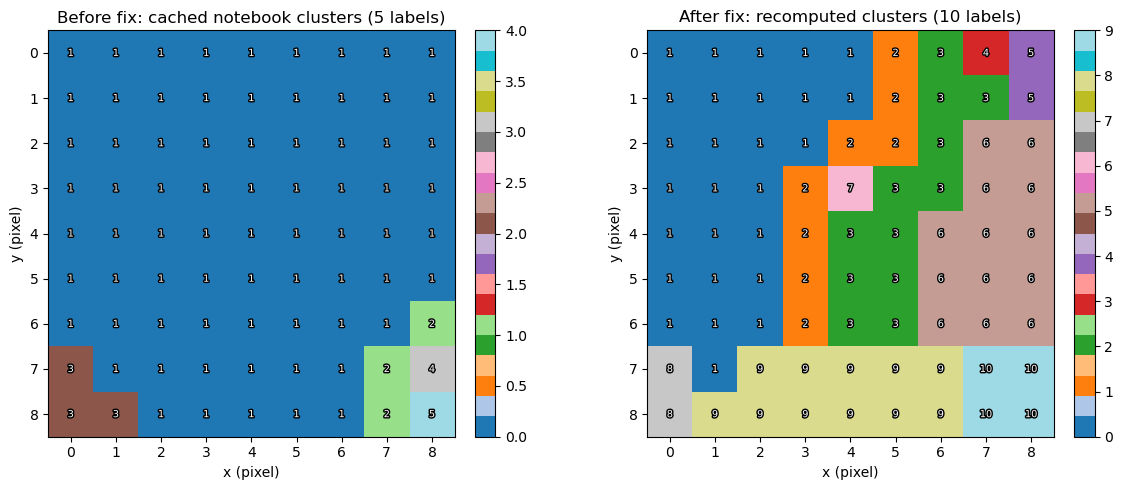

Before fix: cluster 0 size = 73, reachable via kept edges = 27
After fix:  cluster 0 size = 27, reachable via kept edges = 27
The corrected run splits the probe window into more components instead of merging disjoint ones.


In [26]:
from collections import defaultdict, deque
from matplotlib import patheffects as pe

print("="*70)
print("BEFORE vs AFTER: cluster assignment on the same probe window")
print("="*70)

import importlib
import models.SR_ocrp as sr_ocrp
importlib.reload(sr_ocrp)

QuaternionBankClusterer = sr_ocrp.QuaternionBankClusterer
_misorientation_angle_sym = sr_ocrp._misorientation_angle_sym

# Probe window quaternions from the LR input, exactly as used in the diagnosis cell.
win_y, win_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)
lr_q_img = to_hwc_quat(lr_in[0].detach().cpu(), lr_shape)
q_flat_probe = torch.tensor(
    lr_q_img[win_y:win_y + model.ocrp.window_size, win_x:win_x + model.ocrp.window_size],
    dtype=torch.float32,
).reshape(model.ocrp.window_size * model.ocrp.window_size, 4)

# Old clustering from the cached notebook forward pass.
old_cluster_ids = aux['cluster_ids'][0, PROBE_WIN_IDX].detach().cpu().numpy().reshape(model.ocrp.window_size, model.ocrp.window_size)
old_unique = np.unique(old_cluster_ids)

# Fixed clusterer on the same probe window q_flat.
old_clusterer = model.ocrp.clusterer
clusterer_fixed = QuaternionBankClusterer(
    threshold_deg=float(np.rad2deg(old_clusterer.threshold_rad)),
    connectivity=int(old_clusterer.connectivity),
    window_size=int(old_clusterer.window_size),
    sym_ops_quat=torch.tensor([[1, 0, 0, 0]], dtype=torch.float32),
)
clusterer_fixed.sym_ops_mat = old_clusterer.sym_ops_mat
clusterer_fixed.edge_idx_a = old_clusterer.edge_idx_a
clusterer_fixed.edge_idx_b = old_clusterer.edge_idx_b
clusterer_fixed = clusterer_fixed.to(DEVICE)

with torch.no_grad():
    new_cluster_ids_flat = clusterer_fixed(q_flat_probe.unsqueeze(0).unsqueeze(0).to(DEVICE))[0, 0].detach().cpu().numpy()
new_cluster_ids = new_cluster_ids_flat.reshape(model.ocrp.window_size, model.ocrp.window_size)
new_unique = np.unique(new_cluster_ids)

# Reindex labels for clean plotting.
def reindex_map(label_map):
    uniques = np.unique(label_map)
    mapping = {old: new for new, old in enumerate(uniques)}
    return np.vectorize(mapping.get)(label_map), mapping

old_re, old_map = reindex_map(old_cluster_ids)
new_re, new_map = reindex_map(new_cluster_ids)

# Connectivity check for the parent cluster.
edge_a = clusterer_fixed.edge_idx_a.cpu().numpy()
edge_b = clusterer_fixed.edge_idx_b.cpu().numpy()
sym_ops = clusterer_fixed.sym_ops_mat.detach().cpu().to(torch.float32)
q1 = q_flat_probe[edge_a]
q2 = q_flat_probe[edge_b]
mis_deg = (_misorientation_angle_sym(q1, q2, sym_ops) * 180.0 / np.pi).cpu().numpy()
kept_mask = mis_deg <= float(np.rad2deg(clusterer_fixed.threshold_rad))

def bfs_reach(label_map, target_label):
    target_pixels = set(np.where(label_map.reshape(-1) == target_label)[0].tolist())
    adj = defaultdict(set)
    for (ia, ib), keep in zip(zip(edge_a, edge_b), kept_mask):
        if not keep:
            continue
        if ia in target_pixels and ib in target_pixels:
            adj[ia].add(ib)
            adj[ib].add(ia)
    if not target_pixels:
        return 0, 0
    seed = next(iter(target_pixels))
    queue = deque([seed])
    visited = {seed}
    while queue:
        u = queue.popleft()
        for v in adj[u]:
            if v not in visited:
                visited.add(v)
                queue.append(v)
    return len(target_pixels), len(visited)

old_parent_size, old_parent_reach = bfs_reach(old_cluster_ids, 0)
new_parent_size, new_parent_reach = bfs_reach(new_cluster_ids, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, uniq in [
    (axes[0], old_re, f'Before fix: cached notebook clusters ({len(old_unique)} labels)', old_unique),
    (axes[1], new_re, f'After fix: recomputed clusters ({len(new_unique)} labels)', new_unique),
]:
    im = ax.imshow(data, cmap='tab20', interpolation='nearest', vmin=0, vmax=max(0, len(uniq) - 1))
    ax.set_title(title)
    ax.set_xlabel('x (pixel)')
    ax.set_ylabel('y (pixel)')
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            ax.text(x, y, str(int(data[y, x]) + 1), color='white', ha='center', va='center', fontsize=7,
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'Before fix: cluster 0 size = {old_parent_size}, reachable via kept edges = {old_parent_reach}')
print(f'After fix:  cluster 0 size = {new_parent_size}, reachable via kept edges = {new_parent_reach}')
print('The corrected run splits the probe window into more components instead of merging disjoint ones.')
